In [2]:
!pip install mediapipe==0.10.13 -q 
#it installs MediaPipe library into your environment (the brain for pose/hand tracking)

# Can you skip it? YES if mediapipe is already installed NO if you're on Google Colab / fresh environment

**Phase 1 — Pose Detection**

In [3]:
import cv2
# This is OpenCV
# Used for: reading videos, processing frames (images inside video)
import mediapipe as mp
# Used for: detecting human body points (pose landmarks), Like: finding joints → shoulder, elbow, knee
import numpy as np
import pandas as pd
from pathlib import Path
# Helps handle file paths easily, Instead of messy strings → cleaner file handling
import os

# Verify GPU
import torch
print("CUDA available:", torch.cuda.is_available())

# MediaPipe setup
mp_pose = mp.solutions.pose
# Loading pose detection model, This is the brain that finds body joints
mp_drawing = mp.solutions.drawing_utils
# Tool to draw skeleton on body

# Path to your uploaded dataset — adjust dataset name to match yours on Kaggle
VIDEO_DIR = Path('/kaggle/input/datasets/anonymous/tennis-stroke-videos') 
OUTPUT_DIR = Path('/kaggle/working')

# Verify videos are found
video_files = sorted(VIDEO_DIR.glob('*.mp4'))
# This: searches for all .mp4 files and stores them in a list
print(f"\nFound {len(video_files)} videos:")
for v in video_files:
    print(f"  {v.name}")
    # Prints each video name

2026-05-07 11:47:59.408810: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778154479.825587      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778154479.937086      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778154480.934185      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778154480.934246      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778154480.934252      57 computation_placer.cc:177] computation placer alr

CUDA available: True

Found 11 videos:
  Alcaraz video.mp4
  Carlos Alcaraz Casper Ruud CourtLevel Practice Cincinnati 2025.mp4
  Djokovic and Zverev Practice.mp4
  Jannik Sinner Practice.mp4
  Rafael Nadal vs Tommy Paul INTENSE Practice Washington Citi Open Court Level Vi.mp4
  Roger Federer Video.mp4
  Wawrinka Practice.mp4
  back_mixed.mp4
  back_mixed_2.mp4
  front_mixed.mp4
  side_mixed.mp4


In [4]:
import mediapipe as mp
print(mp.__version__)

# In newer mediapipe, solutions API changed
# Test which style works

# MediaPipe changed its API in newer versions, Meaning: Old code → might break, New version → different way to use
try:
    mp_pose = mp.solutions.pose
    print("solutions API works")
except AttributeError:
    print("solutions API broken — need new style")

0.10.13
solutions API works


In [5]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import urllib.request
# Helps you download files from the internet
import mediapipe as mp
# Loads MediaPipe so you can use it
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# Imports specific MediaPipe modules: python → base API. vision → for image/video tasks (pose, hand, face tracking)
# Analogy: Instead of opening full toolbox, you take only: hammer (vision tools), screwdriver (tasks API)
# Can you skip it?NO if you're using pose detection / tennis tracking


print('MediaPipe version:', mp.__version__)
print('All imports successful!')

MediaPipe version: 0.10.13
All imports successful!


In [ ]:
# # Downloading lite model — much faster
# # This cell is about downloading a lightweight pose detection model.
# !wget -q https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_lite/float16/latest/pose_landmarker_lite.task -O /kaggle/working/pose_landmarker_lite.task

# # !wget → command to download file from internet, -q → quiet mode (no extra logs), URL → location of model, -O → where to save file
# # here we are downloading the mediapipe brain from the internet
# print("Lite model downloaded")

In [6]:
!wget -q https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_full/float16/latest/pose_landmarker_full.task -O /kaggle/working/pose_landmarker_full.task

print("Full model downloaded")

Full model downloaded


In [7]:
# so We downloaded the brain earlier, now we are setting how it should behave
# This tells: “Where is my downloaded model file?”


model_path = '/kaggle/working/pose_landmarker_full.task'  # <-- full model
base_options = python.BaseOptions(model_asset_path=model_path)
# Loads this model so I can use it, BaseOptions is like plugging brain into system

options = vision.PoseLandmarkerOptions(
    # This is where we control how the model behaves
    base_options=base_options,
    output_segmentation_masks=False,
    # Means: Don’t detect full body region, Only detect keypoints (joints)
    num_poses=1,
    min_pose_detection_confidence=0.5,
    # Model must be at least 50% sure to detect a person, tar mane we are giving a strictness level here, atleast be 50 % sure, je this is a person, judi 50 t ke 80 kori diu, then strictness will be high, tetia time lagibo pare but model will be very sharp, a good one
    min_pose_presence_confidence=0.5,
    # this checks “Is a person really present? neh kiba ji ti hoi ase
    min_tracking_confidence=0.5
    # While tracking across frames: Must be at least 50% confident
)
print('Full model ready.')

Full model ready.


In [8]:
# in this cell we are giving human-readable names to body points (instead of confusing numbers)
# tar mane ki hoi, mediapipe or output ot generally in the form of numbers ulai, so hence this cell is used to convert those numbers to meaningful names

LANDMARKS = {
    'nose': 0,
    'left_shoulder': 11,  'right_shoulder': 12,
    'left_elbow': 13,     'right_elbow': 14,
    'left_wrist': 15,     'right_wrist': 16,
    'left_hip': 23,       'right_hip': 24,
    'left_knee': 25,      'right_knee': 26,
    'left_ankle': 27,     'right_ankle': 28
}

# so this is a landmarks dictionary, where each number is mapped to a body part, question? - numbers bur keneke gom pala are these random??
# nohoi random nohoi, mediapipe has fixed body structure, 0 mane nose, 11 mane left shoulder and so on
print('Landmarks defined.')

Landmarks defined.


In [9]:
# Test world landmarks availability
test_video = str(next(VIDEO_DIR.glob('*front*')))
cap = cv2.VideoCapture(test_video)
ret, frame = cap.read()
cap.release()

rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)

with vision.PoseLandmarker.create_from_options(options) as landmarker:
    result = landmarker.detect(mp_image)

print("Image landmarks available:", result.pose_landmarks is not None)
print("World landmarks available:", result.pose_world_landmarks is not None)

if result.pose_world_landmarks:
    wlm = result.pose_world_landmarks[0]
    print(f"\nSample world coords (left wrist):")
    print(f"  x: {wlm[15].x:.4f}m")
    print(f"  y: {wlm[15].y:.4f}m")
    print(f"  z: {wlm[15].z:.4f}m")

Image landmarks available: True
World landmarks available: True

Sample world coords (left wrist):
  x: 0.1456m
  y: -0.0893m
  z: -0.2432m


I0000 00:00:1778154543.237137      57 task_runner.cc:85] GPU suport is not available: INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:84) egl_initializedUnable to initialize EGL
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


In [ ]:
# def extract_keypoints(video_path, video_label, player_id, frame_skip=3):
#     cap = cv2.VideoCapture(video_path)
#     fps = cap.get(cv2.CAP_PROP_FPS)
#     total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
#     effective_fps = fps / frame_skip
#     print(f'\nProcessing: {video_label} | {total} frames @ {fps:.1f} FPS')
#     print(f'  Skipping every {frame_skip} frames → effective {effective_fps:.1f} FPS')

#     records = []
#     frame_idx = 0

#     with vision.PoseLandmarker.create_from_options(options) as landmarker:
#         while cap.isOpened():
#             ret, frame = cap.read()
#             if not ret:
#                 break

#             if frame_idx % frame_skip != 0:
#                 frame_idx += 1
#                 continue

#             rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
#             mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
#             result = landmarker.detect(mp_image)

#             row = {
#                 'frame': frame_idx,
#                 'time_sec': frame_idx / fps,
#                 'video': video_label,
#                 'player_id': player_id,
#                 'fps': fps,
#                 'pose_detected': False
#             }

#             if result.pose_landmarks and len(result.pose_landmarks) > 0:
#                 row['pose_detected'] = True
#                 lm  = result.pose_landmarks[0]
#                 wlm = result.pose_world_landmarks[0] if result.pose_world_landmarks else None

#                 for name, idx in LANDMARKS.items():
#                     # Image landmarks (normalized 0-1)
#                     row[f'{name}_x']  = lm[idx].x
#                     row[f'{name}_y']  = lm[idx].y
#                     row[f'{name}_z']  = lm[idx].z
#                     row[f'{name}_vis'] = lm[idx].visibility
#                     # World landmarks (metric, hip as origin)
#                     if wlm:
#                         row[f'{name}_wx'] = wlm[idx].x
#                         row[f'{name}_wy'] = wlm[idx].y
#                         row[f'{name}_wz'] = wlm[idx].z
#                     else:
#                         row[f'{name}_wx'] = np.nan
#                         row[f'{name}_wy'] = np.nan
#                         row[f'{name}_wz'] = np.nan

#             records.append(row)
#             frame_idx += 1

#             if len(records) % 200 == 0:
#                 print(f'  {len(records)} samples collected ({frame_idx}/{total} frames)...')

#     cap.release()
#     df = pd.DataFrame(records)
#     detected = df['pose_detected'].sum()
#     print(f'  Done — pose detected in {detected}/{len(df)} samples ({100*detected/len(df):.1f}%)')
#     return df

# print('Function ready.')

In [10]:
def extract_keypoints(video_path, video_label, player_id):
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    print(f'\nProcessing: {video_label} | {total} frames @ {fps:.1f} FPS')
    
    records = []
    frame_idx = 0
    
    # VIDEO mode enables temporal smoothing between frames
    video_options = vision.PoseLandmarkerOptions(
        base_options=base_options,  # reuse your existing base_options
        running_mode=vision.RunningMode.VIDEO
    )
    
    with vision.PoseLandmarker.create_from_options(video_options) as landmarker:
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break
            
            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
            
            # VIDEO mode requires timestamp in milliseconds
            timestamp_ms = int(frame_idx * 1000 / fps)
            result = landmarker.detect_for_video(mp_image, timestamp_ms)
            
            row = {
                'frame': frame_idx,
                'time_sec': frame_idx / fps,
                'video': video_label,
                'player_id': player_id,
                'fps': fps,
                'pose_detected': False
            }
            
            if result.pose_landmarks and len(result.pose_landmarks) > 0:
                row['pose_detected'] = True
                lm  = result.pose_landmarks[0]
                wlm = result.pose_world_landmarks[0] if result.pose_world_landmarks else None
                
                for name, idx in LANDMARKS.items():
                    # Image landmarks (kept for visualization)
                    row[f'{name}_x']   = lm[idx].x
                    row[f'{name}_y']   = lm[idx].y
                    row[f'{name}_z']   = lm[idx].z
                    row[f'{name}_vis'] = lm[idx].visibility
                    # World landmarks (metric, hip as origin) — used for features
                    if wlm:
                        row[f'{name}_wx'] = wlm[idx].x
                        row[f'{name}_wy'] = wlm[idx].y
                        row[f'{name}_wz'] = wlm[idx].z
                    else:
                        row[f'{name}_wx'] = np.nan
                        row[f'{name}_wy'] = np.nan
                        row[f'{name}_wz'] = np.nan
            
            records.append(row)
            frame_idx += 1
            
            if len(records) % 200 == 0:
                print(f'  {len(records)} samples collected ({frame_idx}/{total} frames)...')
    
    cap.release()
    df = pd.DataFrame(records)
    detected = df['pose_detected'].sum()
    print(f'  Done — pose detected in {detected}/{len(df)} samples ({100*detected/len(df):.1f}%)')
    return df

print('Function ready.')

Function ready.


In [11]:
# Test MediaPipe speed on 50 frames
import time

test_video = str(video_files[0])
cap = cv2.VideoCapture(test_video)

frame_idx = 0
times = []

with vision.PoseLandmarker.create_from_options(options) as landmarker:
    for i in range(50):
        ret, frame = cap.read()
        if not ret:
            break

        start = time.time()
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
        result = landmarker.detect(mp_image)
        elapsed = time.time() - start
        times.append(elapsed)

        if i % 10 == 0:
            print(f"Frame {i}: {elapsed:.3f}s")

cap.release()

avg = sum(times) / len(times)
total_estimated = avg * 21532
print(f"\nAvg per frame: {avg:.3f}s")
print(f"Estimated total for Alcaraz video: {total_estimated/60:.1f} minutes")

I0000 00:00:1778154555.185599      57 task_runner.cc:85] GPU suport is not available: INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:84) egl_initializedUnable to initialize EGL


Frame 0: 0.023s
Frame 10: 0.043s
Frame 20: 0.042s
Frame 30: 0.040s
Frame 40: 0.042s

Avg per frame: 0.040s
Estimated total for Alcaraz video: 14.5 minutes


In [ ]:
# this is my execution cell, It actually runs my whole project on all videos 

def get_player_id(video_stem):
    my_videos = ['back_mixed', 'back_mixed_2', 'front_mixed', 'side_mixed']
    
    if video_stem in my_videos:
        return 'anonymous'
    elif 'Alcaraz' in video_stem or 'alcaraz' in video_stem or 'Carlos' in video_stem:
        return 'alcaraz'
    elif 'Federer' in video_stem or 'federer' in video_stem or 'Roger' in video_stem:
        return 'federer'
    elif 'Djokovic' in video_stem or 'djokovic' in video_stem:
        return 'djokovic'
    elif 'Zverev' in video_stem or 'zverev' in video_stem:
        return 'zverev'
    elif 'Sinner' in video_stem or 'sinner' in video_stem or 'Jannik' in video_stem:
        return 'sinner'
    elif 'Nadal' in video_stem or 'nadal' in video_stem or 'Rafael' in video_stem:
        return 'nadal'
    elif 'Wawrinka' in video_stem or 'wawrinka' in video_stem:
        return 'wawrinka'
    else:
        return 'unknown'

# If no match → unknown player

all_keypoints = []
# empty list to store data from all videos

for video_path in video_files:
    # loop through all video
    player_id = get_player_id(video_path.stem)
    # extract player name, .stem means extract filename without .mp4
    print(f"\nProcessing: {video_path.name} → player_id: {player_id}")
    # show video name, detected player
    
    cap = cv2.VideoCapture(str(video_path))
    fps = cap.get(cv2.CAP_PROP_FPS)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    print(f"  FPS: {fps:.1f}, Total frames: {total}, Est. time: {total//fps//60:.0f} min")
    cap.release()
    # close video
    
    df = extract_keypoints(str(video_path), video_path.stem, player_id)
    # Calls your main function, This does: read frames, detect pose, extract keypoints
    all_keypoints.append(df)
    # stores result of each video

keypoints_df = pd.concat(all_keypoints, ignore_index=True)
# merge all data into one big table
keypoints_df.to_csv(OUTPUT_DIR / 'keypoints.csv', index=False)
# save as csv file
print(f"\nDone. Total rows: {len(keypoints_df)}")
print(keypoints_df['player_id'].value_counts())

In [12]:
import os
# atia ami since model tuk feature keneke extract kore khikalu, atia ami nijor videos bur or logt test korim, sau kenekua kore
# heikarne ami upload korisu tennis videos nijor and then 
# we are Finding the correct path first, before testing and checking ji videos or pics upload korisu heigita e ase neh
base = '/kaggle/input/datasets/anonymous/tennis-stroke-videos'
print('Contents:', os.listdir(base))


Contents: ['back_mixed.mp4', 'front_mixed.mp4', 'Jannik Sinner Practice.mp4', 'Rafael Nadal vs Tommy Paul INTENSE Practice Washington Citi Open Court Level Vi.mp4', 'Djokovic and Zverev Practice.mp4', 'Alcaraz video.mp4', 'back_mixed_2.mp4', 'Wawrinka Practice.mp4', 'Carlos Alcaraz Casper Ruud CourtLevel Practice Cincinnati 2025.mp4', 'side_mixed.mp4', 'Roger Federer Video.mp4']


In [13]:
# this cell is simple also imp, it checks all our videos and prints their details (size, fps, duration, etc.)
# before getting into it, we first look at your data, “What kind of videos do I have?
base = '/kaggle/input/datasets/jigyashmanhazarika/tennis-stroke-videos'
# this is where our videos is stored
videos = os.listdir(base)
# gets all file names inside that folder

print(f'Found {len(videos)} videos:\n')
# prints no of videos
for v in videos:
    # loop through each video, Go one by one: video1.mp4, video2.mp4, etc.
    path = os.path.join(base, v)
    # Combine folder + file name
    size = os.path.getsize(path) / (1024*1024)
    # gets size in MB
    
    # Get video properties
    import cv2
    cap = cv2.VideoCapture(path)
    # Open video (same as before)
    fps = cap.get(cv2.CAP_PROP_FPS)
    # extract video properties, frames per second
    frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    # total frames
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    # Resolution (width × height)
    duration = frames / fps if fps > 0 else 0
    # total duration of video
    cap.release()
    # close video, free memory
    
    print(f'{v}')
    print(f'  Size: {size:.1f} MB | Resolution: {w}x{h} | FPS: {fps:.1f} | Duration: {duration:.1f}s | Frames: {frames}')
    #shows info neatly

Found 11 videos:

back_mixed.mp4
  Size: 5.7 MB | Resolution: 464x832 | FPS: 60.0 | Duration: 38.7s | Frames: 2318
front_mixed.mp4
  Size: 6.7 MB | Resolution: 464x832 | FPS: 60.0 | Duration: 45.5s | Frames: 2726
Jannik Sinner Practice.mp4
  Size: 113.3 MB | Resolution: 1280x720 | FPS: 60.0 | Duration: 488.8s | Frames: 29330
Rafael Nadal vs Tommy Paul INTENSE Practice Washington Citi Open Court Level Vi.mp4
  Size: 152.4 MB | Resolution: 1280x720 | FPS: 60.0 | Duration: 582.0s | Frames: 34918
Djokovic and Zverev Practice.mp4
  Size: 167.0 MB | Resolution: 1280x720 | FPS: 59.9 | Duration: 486.7s | Frames: 29174
Alcaraz video.mp4
  Size: 26.6 MB | Resolution: 640x360 | FPS: 30.0 | Duration: 718.5s | Frames: 21532
back_mixed_2.mp4
  Size: 5.2 MB | Resolution: 464x832 | FPS: 60.0 | Duration: 35.4s | Frames: 2122
Wawrinka Practice.mp4
  Size: 94.0 MB | Resolution: 1280x720 | FPS: 50.0 | Duration: 332.5s | Frames: 16624
Carlos Alcaraz Casper Ruud CourtLevel Practice Cincinnati 2025.mp4
  Siz

In [ ]:
# Verify saved correctly
keypoints_df = pd.read_csv(OUTPUT_DIR / 'keypoints.csv')
print(f"Shape: {keypoints_df.shape}")
print(f"\nColumns: {list(keypoints_df.columns[:10])}...")
print(f"\nPer video sample counts:")
print(keypoints_df.groupby(['player_id', 'video'])['frame'].count())
print(f"\nMissing values in key landmarks:")
print(keypoints_df[['left_wrist_x', 'right_wrist_x', 'left_elbow_x']].isna().sum())

**Phase 2 — Stroke Detection**

In [15]:
from pathlib import Path

OUTPUT_DIR = Path('/kaggle/input/datasets/anonymous/tennis-keypoints-anonymous')

keypoints_df = pd.read_csv(OUTPUT_DIR / 'keypoints.csv')
print(f"Loaded {len(keypoints_df)} rows")

Loaded 172611 rows


In [16]:
# THIS is your intelligence layer, Earlier we extracted body points, Now we are detecting actual tennis strokes

keypoints_df = pd.read_csv('/kaggle/input/datasets/anonymous/tennis-keypoints-anonymous/keypoints.csv')
def detect_strokes_v3(df, player_id,
                       velocity_threshold=0.04,
                       min_gap_frames=90,  # increased from 20
                       window=15):
    # Input: df → your keypoints dataset, player_id → which player, other parameters → control detection
    # goal: find when a tennis stroke happens
    player_df = df[df['player_id'] == player_id].copy()
    # Take only data of one player, Example: only Federer OR only you
    all_strokes = []

    for video_name in player_df['video'].unique():
        # process each video separately
        vid_df = player_df[player_df['video'] == video_name].copy()
        # stores a copy of the video, for later use
        vid_df = vid_df[vid_df['pose_detected'] == True].reset_index(drop=True)
        # removes bad frames ( no pose)
        if len(vid_df) < 10:
            continue
        # skip very small videos

        # Compute Movement (VERY IMPORTANT)
        vid_df['lw_vx'] = vid_df['left_wrist_wx'].diff().abs()
        # Change in wrist position, .diff() = movement from previous frame
        vid_df['lw_vy'] = vid_df['left_wrist_wy'].diff().abs()
        vid_df['rw_vx'] = vid_df['right_wrist_wx'].diff().abs()
        vid_df['rw_vy'] = vid_df['right_wrist_wy'].diff().abs()
        vid_df['wrist_velocity'] = vid_df[['lw_vx','lw_vy','rw_vx','rw_vy']].max(axis=1)
        # take maximum movement of both wrists, meaning how fast hand is moving
        
        vid_df['le_vy'] = vid_df['left_elbow_wy'].diff().abs()
        vid_df['re_vy'] = vid_df['right_elbow_wy'].diff().abs()
        vid_df['elbow_movement'] = vid_df[['le_vy','re_vy']].max(axis=1)

        vid_df['ls_vy'] = vid_df['left_shoulder_wy'].diff().abs()
        vid_df['rs_vy'] = vid_df['right_shoulder_wy'].diff().abs()
        vid_df['shoulder_movement'] = vid_df[['ls_vy','rs_vy']].max(axis=1)
        # same goes for shoulder and elbow movement

        vid_df['stroke_score'] = (
            vid_df['wrist_velocity'] * 0.5 +
            vid_df['elbow_movement'] * 0.3 +
            vid_df['shoulder_movement'] * 0.2
        )

        # combine all movements into one number (Weights) but why?? big movement (or weights) = high score means possible stroke hitten
        vid_df['stroke_score_smooth'] = vid_df['stroke_score'].rolling(3, center=True).mean()
        # rolling(3, center=True).mean(), it smooths noise

        # Find peaks — only keep LOCAL maxima above threshold
        stroke_frames = []
        last_stroke = -min_gap_frames

        for i in range(1, len(vid_df) - 1):
            # checks each frame
            score = vid_df.iloc[i]['stroke_score_smooth']
            if pd.isna(score):
                continue
            prev_score = vid_df.iloc[i-1]['stroke_score_smooth']
            next_score = vid_df.iloc[i+1]['stroke_score_smooth']

            # Must be local maximum AND above threshold AND far enough from last stroke
            is_local_max = score > prev_score and score > next_score
            # peak point
            above_threshold = score > velocity_threshold
            # movement must be strong enough
            far_enough = (i - last_stroke) >= min_gap_frames
            # avoid detecting same stroke multiple times

            if is_local_max and above_threshold and far_enough:
                stroke_frames.append(i)
                last_stroke = i

            # You are basically saying: Find peaks,Only big peaks, Only spaced peaks = strokes detected

        for peak in stroke_frames:
            # For each detected stroke
            start = max(0, peak - window)
            end = min(len(vid_df), peak + window)
            # Take frames around stroke
            # means capture before + after motion

            all_strokes.append({
                'video': video_name,
                'player_id': player_id,
                'peak_frame': vid_df.iloc[peak]['frame'],
                'peak_time_sec': vid_df.iloc[peak]['time_sec'],
                'window_start': vid_df.iloc[start]['frame'],
                'window_end': vid_df.iloc[end-1]['frame'],
                'max_stroke_score': vid_df.iloc[peak]['stroke_score_smooth'],
                'n_frames_in_window': len(vid_df.iloc[start:end])
            })
            # Save: video name, player, peak frame, time, window, score

    return pd.DataFrame(all_strokes)

# Per player thresholds

player_thresholds = {
    'alcaraz':  0.08,
    'federer':  0.07,
    'djokovic': 0.07,
    'zverev':   0.07,
    'sinner':   0.07,
    'nadal':    0.07,
    'wawrinka': 0.07,
    'anonymous':    0.04
}


all_strokes_v3 = []
for pid in keypoints_df['player_id'].unique():
    threshold = player_thresholds.get(pid, 0.04)
    strokes = detect_strokes_v3(keypoints_df, pid,
                                 velocity_threshold=threshold,
                                 min_gap_frames=40)
    print(f"{pid}: {len(strokes)} strokes detected")
    all_strokes_v3.append(strokes)

stroke_windows_df = pd.concat(all_strokes_v3, ignore_index=True)
# Merge all players
stroke_windows_df.to_csv('/kaggle/working/stroke_windows.csv', index=False)
# save output
print(f"\nTotal: {len(stroke_windows_df)}")
print(stroke_windows_df.groupby('player_id')['peak_frame'].count())

alcaraz: 386 strokes detected
djokovic: 138 strokes detected
sinner: 216 strokes detected
nadal: 195 strokes detected
federer: 173 strokes detected
wawrinka: 91 strokes detected
jiggs: 82 strokes detected

Total: 1281
player_id
alcaraz     386
djokovic    138
federer     173
jiggs        82
nadal       195
sinner      216
wawrinka     91
Name: peak_frame, dtype: int64


In [17]:
print(f"Total strokes: {len(stroke_windows_df)}")
print(f"Valid stroke_ids: 0 to {len(stroke_windows_df) - 1}")

Total strokes: 1281
Valid stroke_ids: 0 to 1280


In [18]:
from pathlib import Path

VIDEO_DIR = Path('/kaggle/input/datasets/anonymous/tennis-stroke-videos')  # replace with your actual video dataset name

stroke_windows_df = pd.read_csv('/kaggle/working/stroke_windows.csv')
print(f"Loaded {len(stroke_windows_df)} strokes")

Loaded 1281 strokes


I0000 00:00:1778154687.650190      57 task_runner.cc:85] GPU suport is not available: INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:84) egl_initializedUnable to initialize EGL


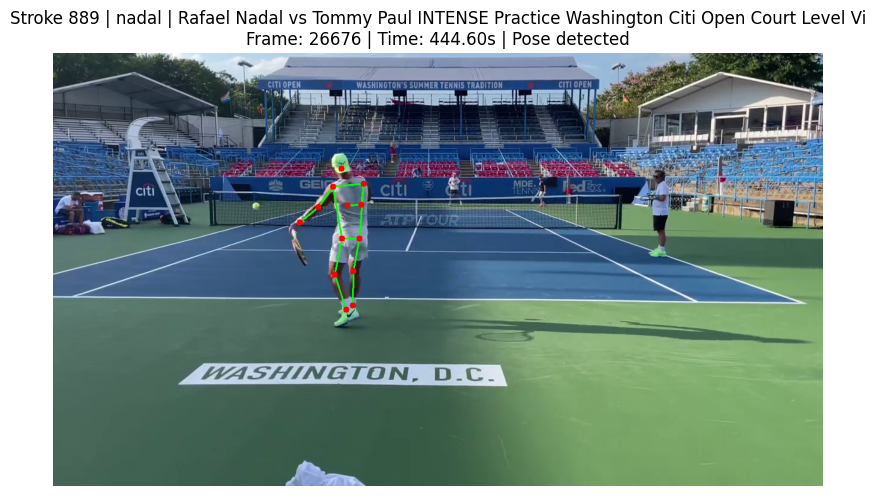

Stroke 889 → nadal | Rafael Nadal vs Tommy Paul INTENSE Practice Washington Citi Open Court Level Vi | 444.60s


In [23]:
# Sanity check — visualize stroke frame for any stroke_id
def visualize_stroke(stroke_id, show_info=True):
    row = stroke_windows_df.iloc[stroke_id]
    video_name = row['video']
    peak_frame = int(row['peak_frame'])
    player_id = row['player_id']
    peak_time = row['peak_time_sec']

    # Find video file
    video_path = next(VIDEO_DIR.glob(f'*{video_name}*'), None)
    if video_path is None:
        # Try partial match
        for v in VIDEO_DIR.glob('*.mp4'):
            if any(word in v.stem for word in video_name.split()):
                video_path = v
                break
    if video_path is None:
        print(f"Video file not found for: {video_name}")
        return

    cap = cv2.VideoCapture(str(video_path))
    cap.set(cv2.CAP_PROP_POS_FRAMES, peak_frame)
    ret, frame = cap.read()
    cap.release()

    if not ret:
        print(f"Could not read frame {peak_frame}")
        return

    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)

    with vision.PoseLandmarker.create_from_options(options) as landmarker:
        result = landmarker.detect(mp_image)

    annotated = rgb.copy()
    if result.pose_landmarks and len(result.pose_landmarks) > 0:
        lm = result.pose_landmarks[0]
        h, w = annotated.shape[:2]

        connections = [
            (11,12),(11,13),(13,15),(12,14),(14,16),
            (11,23),(12,24),(23,24),(23,25),(24,26),
            (25,27),(26,28)
        ]
        for a, b in connections:
            x1, y1 = int(lm[a].x * w), int(lm[a].y * h)
            x2, y2 = int(lm[b].x * w), int(lm[b].y * h)
            cv2.line(annotated, (x1,y1), (x2,y2), (0,255,0), 2)

        for name, idx in LANDMARKS.items():
            x, y = int(lm[idx].x * w), int(lm[idx].y * h)
            cv2.circle(annotated, (x, y), 5, (255,0,0), -1)

        pose_status = "Pose detected"
    else:
        pose_status = "No pose detected"

    plt.figure(figsize=(8, 6))
    plt.imshow(annotated)
    if show_info:
        plt.title(f"Stroke {stroke_id} | {player_id} | {video_name}\n"
                  f"Frame: {peak_frame} | Time: {peak_time:.2f}s | {pose_status}")
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    print(f"Stroke {stroke_id} → {player_id} | {video_name} | {peak_time:.2f}s")

# Test it — change stroke_id to any number 0-1280
visualize_stroke(stroke_id=889)

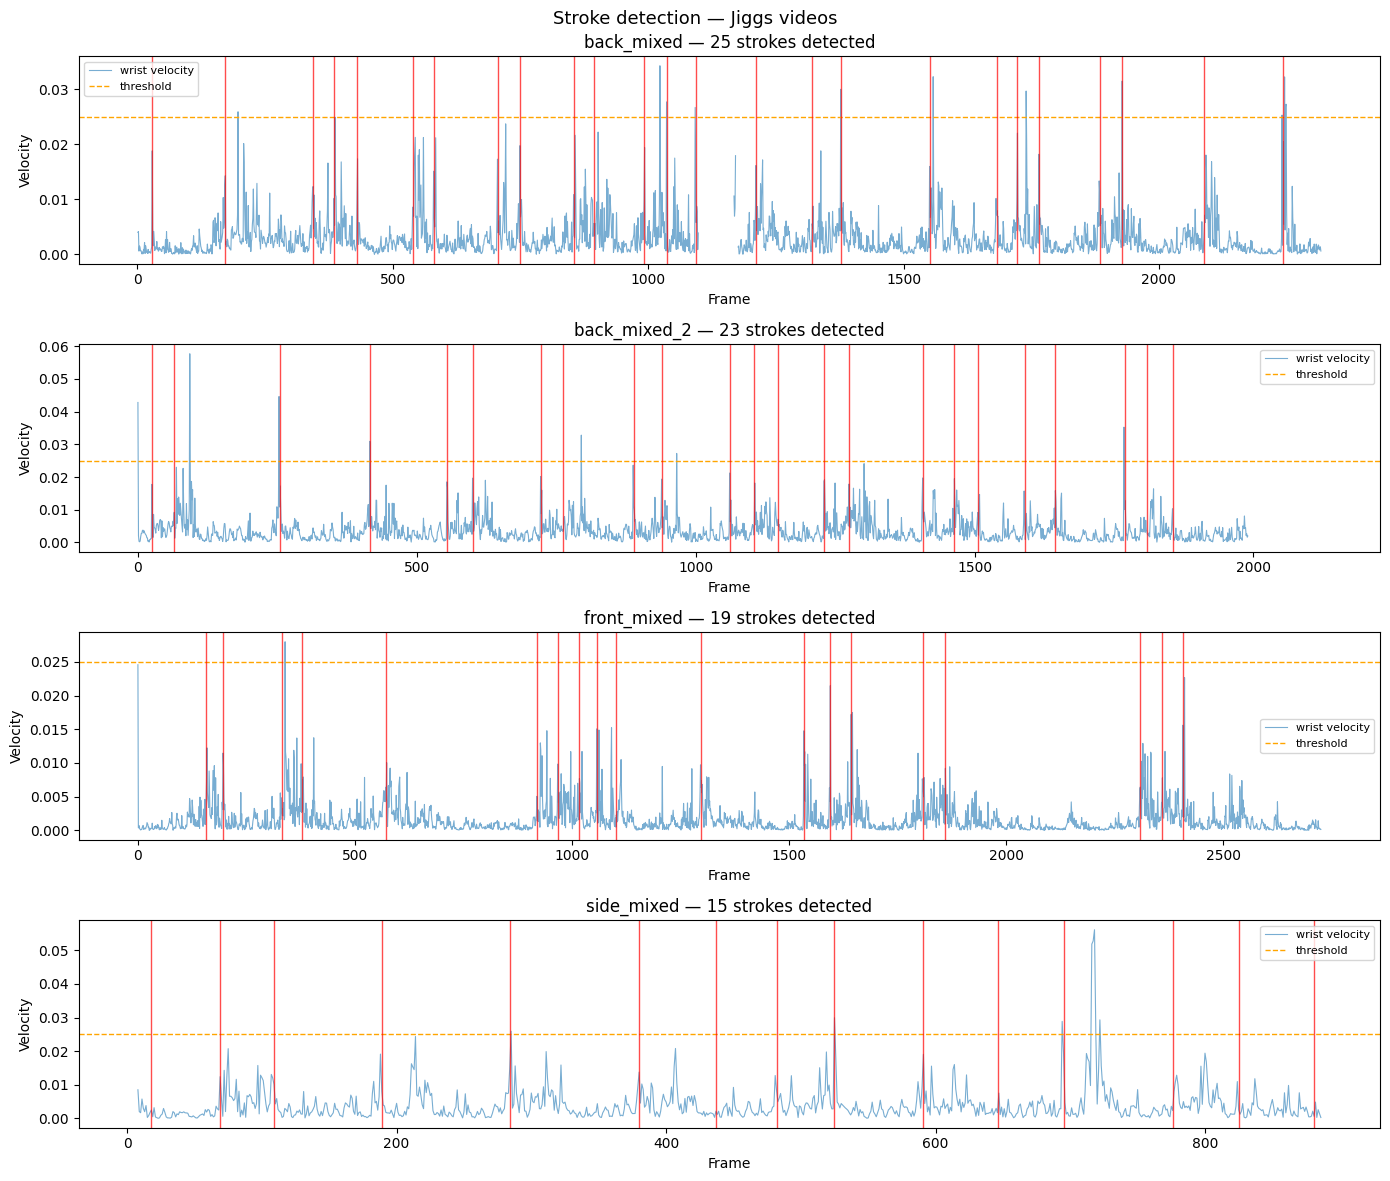

In [24]:
# Visualize stroke timing for your videos
import matplotlib.pyplot as plt

jiggs_strokes = stroke_windows_df[stroke_windows_df['player_id'] == 'jiggs']
jiggs_keypoints = keypoints_df[keypoints_df['player_id'] == 'jiggs'].copy()

# Compute stroke score for plotting
jiggs_keypoints['lw_vy'] = jiggs_keypoints['left_wrist_y'].diff().abs()
jiggs_keypoints['rw_vy'] = jiggs_keypoints['right_wrist_y'].diff().abs()
jiggs_keypoints['wrist_velocity'] = jiggs_keypoints[['lw_vy','rw_vy']].max(axis=1)

fig, axes = plt.subplots(4, 1, figsize=(14, 12))
fig.suptitle('Stroke detection — Jiggs videos', fontsize=13)

for ax, video_name in zip(axes, jiggs_keypoints['video'].unique()):
    vid_kp = jiggs_keypoints[jiggs_keypoints['video'] == video_name]
    vid_strokes = jiggs_strokes[jiggs_strokes['video'] == video_name]

    ax.plot(vid_kp['frame'], vid_kp['wrist_velocity'], 
            alpha=0.6, linewidth=0.8, label='wrist velocity')
    ax.axhline(0.025, color='orange', linestyle='--', linewidth=1, label='threshold')

    for _, stroke in vid_strokes.iterrows():
        ax.axvline(stroke['peak_frame'], color='red', alpha=0.7, linewidth=1)

    ax.set_title(f"{video_name} — {len(vid_strokes)} strokes detected")
    ax.set_xlabel('Frame')
    ax.set_ylabel('Velocity')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('/kaggle/working/stroke_detection_anonymous.png', dpi=150, bbox_inches='tight')
plt.show()

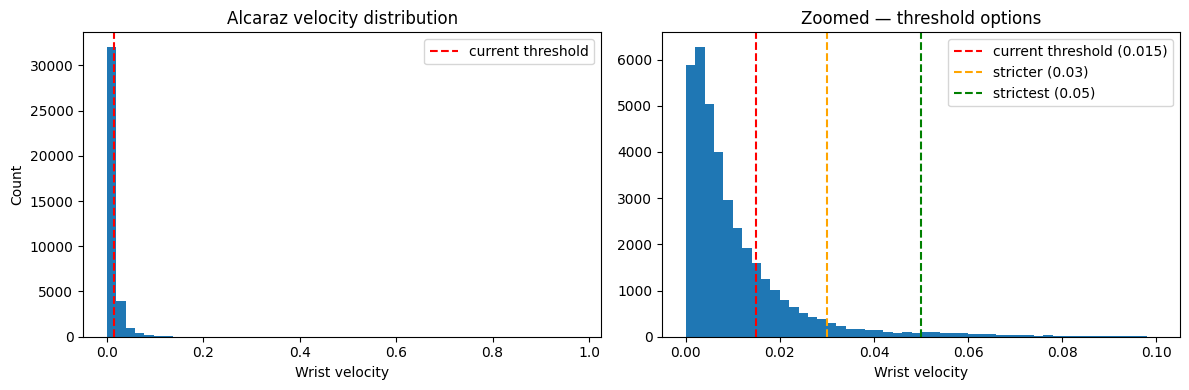

Frames above 0.015: 8428
Frames above 0.030: 2650
Frames above 0.050: 1134


In [25]:
# Check velocity distribution to see if threshold needs tuning
import matplotlib.pyplot as plt

alcaraz_df = keypoints_df[
    (keypoints_df['player_id'] == 'alcaraz') &
    (keypoints_df['pose_detected'] == True)
].copy()

alcaraz_df['lw_vy'] = alcaraz_df['left_wrist_y'].diff().abs()
alcaraz_df['rw_vy'] = alcaraz_df['right_wrist_y'].diff().abs()
alcaraz_df['wrist_velocity'] = alcaraz_df[['lw_vy', 'rw_vy']].max(axis=1)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(alcaraz_df['wrist_velocity'].dropna(), bins=50)
plt.axvline(0.015, color='red', linestyle='--', label='current threshold')
plt.xlabel('Wrist velocity')
plt.ylabel('Count')
plt.title('Alcaraz velocity distribution')
plt.legend()

plt.subplot(1, 2, 2)
# Zoom into lower end
plt.hist(alcaraz_df['wrist_velocity'].dropna(), bins=50, range=(0, 0.1))
plt.axvline(0.015, color='red', linestyle='--', label='current threshold (0.015)')
plt.axvline(0.03, color='orange', linestyle='--', label='stricter (0.03)')
plt.axvline(0.05, color='green', linestyle='--', label='strictest (0.05)')
plt.xlabel('Wrist velocity')
plt.title('Zoomed — threshold options')
plt.legend()

plt.tight_layout()
plt.show()

print(f"Frames above 0.015: {(alcaraz_df['wrist_velocity'] > 0.015).sum()}")
print(f"Frames above 0.030: {(alcaraz_df['wrist_velocity'] > 0.030).sum()}")
print(f"Frames above 0.050: {(alcaraz_df['wrist_velocity'] > 0.050).sum()}")

In [26]:
# V3 stroke summary
print('Stroke Detection Summary — V3')
print('=' * 40)
print(f'Total stroke windows : {len(stroke_windows_df)}')
print()
print(stroke_windows_df.groupby(['player_id', 'video'])['peak_frame'].count().to_string())
print()
print(f"Avg window size: {stroke_windows_df['n_frames_in_window'].mean():.1f} frames")
print(f"Min window size: {stroke_windows_df['n_frames_in_window'].min()}")
print(f"Max window size: {stroke_windows_df['n_frames_in_window'].max()}")

# Check overlaps
print('\nChecking overlapping windows per video...')
for video in stroke_windows_df['video'].unique():
    vid = stroke_windows_df[stroke_windows_df['video'] == video].sort_values('window_start')
    overlaps = 0
    for i in range(len(vid)-1):
        if vid.iloc[i]['window_end'] > vid.iloc[i+1]['window_start']:
            overlaps += 1
    print(f"  {video}: {overlaps} overlapping windows")

Stroke Detection Summary — V3
Total stroke windows : 1281

player_id  video                                                                          
alcaraz    Alcaraz video                                                                      263
           Carlos Alcaraz Casper Ruud CourtLevel Practice Cincinnati 2025                     123
djokovic   Djokovic and Zverev Practice                                                       138
federer    Roger Federer Video                                                                173
jiggs      back_mixed                                                                          25
           back_mixed_2                                                                        23
           front_mixed                                                                         19
           side_mixed                                                                          15
nadal      Rafael Nadal vs Tommy Paul INTENSE Practice Washington 

**Phase 3: Annotation**

In [ ]:
# Export ALL players for manual labeling
all_strokes_to_label = stroke_windows_df.copy()
all_strokes_to_label = all_strokes_to_label.reset_index(drop=True)
all_strokes_to_label['stroke_id'] = all_strokes_to_label.index
all_strokes_to_label['direction'] = ''
all_strokes_to_label['stroke_type'] = ''
all_strokes_to_label['posture_quality'] = ''

all_strokes_to_label[['stroke_id', 'player_id', 'video', 'peak_time_sec',
                        'direction', 'stroke_type', 'posture_quality']].to_csv(
    OUTPUT_DIR / 'anonymous_final_labels.csv', index=False
)
print(f"Total strokes to label: {len(all_strokes_to_label)}")
print(f"\nBreakdown:")
print(all_strokes_to_label.groupby(['player_id', 'video'])['stroke_id'].count().to_string())
print(f"\nLabel options:")
print("  direction      : cross_court / down_the_line / body")
print("  stroke_type    : forehand / backhand / serve")
print("  posture_quality: good / ok / poor")
print(f"\nSaved to {OUTPUT_DIR / 'jiggs_final_labels.csv'}")

In [ ]:
# Print timestamps with correct stroke_id matching labels_todo.csv
for video in stroke_windows_df['video'].unique():
    vid = stroke_windows_df[stroke_windows_df['video'] == video].copy()
    vid = vid.reset_index(drop=True)
    player = vid['player_id'].iloc[0]
    
    # Get the actual CSV row indices for this video
    csv_indices = stroke_windows_df[stroke_windows_df['video'] == video].index.tolist()
    
    print(f"\n{'='*50}")
    print(f"Video: {video} | Player: {player} | {len(vid)} strokes")
    print(f"{'='*50}")
    print(f"{'CSV Row':<12} {'Time (sec)':<14} {'Time (min:sec)'}")
    print(f"{'-'*40}")
    
    for i, (_, row) in enumerate(vid.iterrows()):
        t = row['peak_time_sec']
        mins = int(t // 60)
        secs = t % 60
        csv_row = csv_indices[i]  # this matches stroke_id in labels_todo.csv
        print(f"  {csv_row:<12} {t:<14.2f} {mins}:{secs:05.2f}")

In [27]:
import os

path = '/kaggle/input/datasets/anonymous/anonymous-final-labels/anonymous_final_labels_new.csv'
print('File exists:', os.path.exists(path))
print('Size:', os.path.getsize(path), 'bytes')

# Also list everything in working directory
print('\nAll files in /kaggle/working/:')
for f in os.listdir('/kaggle/working/'):
    size = os.path.getsize(f'/kaggle/working/{f}')
    print(f'  {f} — {size} bytes')

File exists: True
Size: 109246 bytes

All files in /kaggle/working/:
  pose_landmarker_full.task — 9398198 bytes
  stroke_detection_jiggs.png — 434768 bytes
  .virtual_documents — 4096 bytes
  stroke_windows.csv — 120861 bytes


In [28]:
# Load your completed labels
labels_df = pd.read_csv('/kaggle/input/datasets/anonymous/jiggs-final-labels/jiggs_final_labels_new.csv')

print(f"Shape: {labels_df.shape}")
print(f"\nColumns: {list(labels_df.columns)}")
print(f"\nFirst few rows:")
print(labels_df.head())

print(f"\nLabel completeness:")
print(f"  direction filled:       {labels_df['direction'].notna().sum()} / {len(labels_df)}")
print(f"  stroke_type filled:     {labels_df['stroke_type'].notna().sum()} / {len(labels_df)}")
print(f"  posture_quality filled: {labels_df['posture_quality'].notna().sum()} / {len(labels_df)}")

print(f"\nDirection distribution:")
print(labels_df['direction'].value_counts())

print(f"\nStroke type distribution:")
print(labels_df['stroke_type'].value_counts())

print(f"\nPosture quality distribution:")
print(labels_df['posture_quality'].value_counts())

Shape: (1281, 9)

Columns: ['stroke_id', 'player_id', 'video', 'peak_time_sec', 'direction', 'stroke_type', 'posture_quality', 'Unnamed: 7', 'Unnamed: 8']

First few rows:
   stroke_id player_id          video  peak_time_sec    direction stroke_type  \
0          0   alcaraz  Alcaraz video       4.537871       centre    forehand   
1          1   alcaraz  Alcaraz video      11.878545  cross-court    backhand   
2          2   alcaraz  Alcaraz video      14.514515       centre    forehand   
3          3   alcaraz  Alcaraz video      17.050384       centre    forehand   
4          4   alcaraz  Alcaraz video      19.552886       centre    forehand   

  posture_quality  Unnamed: 7  Unnamed: 8  
0             bad         NaN         NaN  
1            good         NaN         NaN  
2            good         NaN         NaN  
3            good         NaN         NaN  
4             bad         NaN         NaN  

Label completeness:
  direction filled:       1281 / 1281
  stroke_type fill

In [29]:
# Standardize label values
labels_df['direction'] = labels_df['direction'].str.strip().str.lower()
labels_df['direction'] = labels_df['direction'].replace({
    'cross-court': 'cross_court',
    'cross court': 'cross_court',
    'down the line': 'down_the_line',
    'down-the-line': 'down_the_line',
    'centre': 'center',
    'center': 'center'
})

labels_df['stroke_type'] = labels_df['stroke_type'].str.strip().str.lower()
labels_df['posture_quality'] = labels_df['posture_quality'].str.strip().str.lower()

# Verify
print("Direction:", labels_df['direction'].unique())
print("Stroke type:", labels_df['stroke_type'].unique())
print("Posture quality:", labels_df['posture_quality'].unique())

# Save cleaned version
labels_df.to_csv('/kaggle/working/labels_clean.csv', index=False)
print("\nSaved labels_clean.csv")

Direction: ['center' 'cross_court' 'down_the_line']
Stroke type: ['forehand' 'backhand']
Posture quality: ['bad' 'good']

Saved labels_clean.csv


In [30]:
labels_final = pd.read_csv('/kaggle/input/datasets/anonymous/anonymous-final-labels/anonymous_final_labels_new.csv')

# Rename to match what the code expects
labels_final = labels_final.rename(columns={
    'direction': 'direction_label',
    'stroke_type': 'stroke_label',
    'posture_quality': 'posture_label'
})

# Drop the empty columns
labels_final = labels_final.drop(columns=['Unnamed: 7', 'Unnamed: 8'])

print(labels_final.columns.tolist())
print(labels_final.shape)

['stroke_id', 'player_id', 'video', 'peak_time_sec', 'direction_label', 'stroke_label', 'posture_label']
(1281, 7)


**Phase 4 feature extraction**

In [31]:
from sklearn.preprocessing import LabelEncoder
import json

# Encode labels
direction_enc = LabelEncoder()
stroke_enc = LabelEncoder()
posture_enc = LabelEncoder()

labels_df['direction_label'] = direction_enc.fit_transform(labels_df['direction'])
labels_df['stroke_label'] = stroke_enc.fit_transform(labels_df['stroke_type'])
labels_df['posture_label'] = posture_enc.fit_transform(labels_df['posture_quality'])

# Save encoder mappings so we can decode predictions later
mappings = {
    'direction': dict(zip(direction_enc.classes_.tolist(), 
                         range(len(direction_enc.classes_)))),
    'stroke_type': dict(zip(stroke_enc.classes_.tolist(), 
                            range(len(stroke_enc.classes_)))),
    'posture_quality': dict(zip(posture_enc.classes_.tolist(), 
                                range(len(posture_enc.classes_))))
}

with open('/kaggle/working/label_encodings.json', 'w') as f:
    json.dump(mappings, f, indent=2)

print("Label encodings:")
for task, mapping in mappings.items():
    print(f"  {task}: {mapping}")

Label encodings:
  direction: {'center': 0, 'cross_court': 1, 'down_the_line': 2}
  stroke_type: {'backhand': 0, 'forehand': 1}
  posture_quality: {'bad': 0, 'good': 1}


In [32]:
# Feature extraction — convert each stroke window into fixed-size sequence
# Each stroke = 30 frames x N keypoint features per frame

SEQUENCE_LEN = 30  # fixed window size

# Which landmarks to use — biomechanically relevant for tennis
RELEVANT_LANDMARKS = [
    'nose',
    'left_shoulder', 'right_shoulder',
    'left_elbow', 'right_elbow',
    'left_wrist', 'right_wrist',
    'left_hip', 'right_hip',
    'left_knee', 'right_knee',
    'left_ankle', 'right_ankle'
]

# Build feature columns — x, y, z for each landmark
# Instead of image landmarks
feature_cols = []
for lm in RELEVANT_LANDMARKS:
    for axis in ['wx', 'wy', 'wz']:  # <-- change x,y,z to wx,wy,wz
        col = f'{lm}_{axis}'
        if col in keypoints_df.columns:
            feature_cols.append(col)

print(f"Using {len(RELEVANT_LANDMARKS)} landmarks x 3 axes = {len(feature_cols)} features per frame")
print(f"Sequence length: {SEQUENCE_LEN} frames")
print(f"Input shape per stroke: ({SEQUENCE_LEN}, {len(feature_cols)})")

# We'll append derived features later in extract_stroke_sequence
# Final input_dim = len(feature_cols) + N_derived (computed dynamically)
print(f"Base landmarks: {len(RELEVANT_LANDMARKS)} x 3 = {len(feature_cols)} features")
print(f"Derived features will be appended per frame in extraction")

Using 13 landmarks x 3 axes = 39 features per frame
Sequence length: 30 frames
Input shape per stroke: (30, 39)
Base landmarks: 13 x 3 = 39 features
Derived features will be appended per frame in extraction


In [33]:
import numpy as np
from scipy.interpolate import interp1d

# ── Landmark index helpers ──────────────────────────────────────────────────
# Maps landmark name → position in feature_cols (base wx block)
def get_xyz(frame_row, lm, feature_cols):
    """Extract (x,y,z) world coords for a landmark from a single frame vector."""
    idx_x = feature_cols.index(f'{lm}_wx')
    return frame_row[idx_x], frame_row[idx_x+1], frame_row[idx_x+2]

def angle_between(a, b, c):
    """
    Angle at joint B formed by A-B-C.
    a, b, c are (x,y,z) tuples.
    Returns angle in degrees.
    """
    a, b, c = np.array(a), np.array(b), np.array(c)
    ba = a - b
    bc = c - b
    cos_angle = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc) + 1e-8)
    return np.degrees(np.arccos(np.clip(cos_angle, -1.0, 1.0)))

In [34]:
def compute_derived_features(frame_row, feature_cols):
    """
    Compute biomechanical derived features from a single frame.
    Returns a 1D numpy array of derived values.
    
    Features:
      - Right elbow angle (shoulder-elbow-wrist)
      - Left elbow angle
      - Right shoulder angle (hip-shoulder-elbow)
      - Left shoulder angle
      - Shoulder-hip rotation (yaw — key for direction)
      - Trunk lean (nose-to-hip vertical angle)
      - Hip width (lateral stance)
      - Knee bend right (hip-knee-ankle)
      - Knee bend left
    """
    rs = get_xyz(frame_row, 'right_shoulder', feature_cols)
    ls = get_xyz(frame_row, 'left_shoulder',  feature_cols)
    re = get_xyz(frame_row, 'right_elbow',    feature_cols)
    le = get_xyz(frame_row, 'left_elbow',     feature_cols)
    rw = get_xyz(frame_row, 'right_wrist',    feature_cols)
    lw = get_xyz(frame_row, 'left_wrist',     feature_cols)
    rh = get_xyz(frame_row, 'right_hip',      feature_cols)
    lh = get_xyz(frame_row, 'left_hip',       feature_cols)
    rk = get_xyz(frame_row, 'right_knee',     feature_cols)
    lk = get_xyz(frame_row, 'left_knee',      feature_cols)
    ra = get_xyz(frame_row, 'right_ankle',    feature_cols)
    la = get_xyz(frame_row, 'left_ankle',     feature_cols)
    nose = get_xyz(frame_row, 'nose',         feature_cols)

    # Joint angles
    r_elbow_angle   = angle_between(rs, re, rw)
    l_elbow_angle   = angle_between(ls, le, lw)
    r_shoulder_angle = angle_between(rh, rs, re)
    l_shoulder_angle = angle_between(lh, ls, le)
    r_knee_angle    = angle_between(rh, rk, ra)
    l_knee_angle    = angle_between(lh, lk, la)

    # Shoulder-hip rotation (yaw in xz plane — most informative for direction)
    shoulder_vec = np.array(rs) - np.array(ls)
    hip_vec      = np.array(rh) - np.array(lh)
    # Signed rotation angle in xz plane
    shoulder_yaw = np.arctan2(shoulder_vec[2], shoulder_vec[0])
    hip_yaw      = np.arctan2(hip_vec[2],      hip_vec[0])
    rotation_diff = np.degrees(shoulder_yaw - hip_yaw)  # trunk rotation

    # Trunk lean — nose relative to hip midpoint, vertical angle
    hip_mid  = (np.array(rh) + np.array(lh)) / 2
    trunk_vec = np.array(nose) - hip_mid
    trunk_lean = np.arctan2(trunk_vec[0], trunk_vec[1])  # forward lean in radians

    # Lateral stance width (hip spread in x)
    hip_width = abs(np.array(rh)[0] - np.array(lh)[0])

    # Wrist height relative to shoulder midpoint (arm position)
    shoulder_mid_y = (np.array(rs)[1] + np.array(ls)[1]) / 2
    r_wrist_rel_height = np.array(rw)[1] - shoulder_mid_y
    l_wrist_rel_height = np.array(lw)[1] - shoulder_mid_y

    return np.array([
        r_elbow_angle, l_elbow_angle,
        r_shoulder_angle, l_shoulder_angle,
        r_knee_angle, l_knee_angle,
        rotation_diff,       # ← most important for direction
        trunk_lean,
        hip_width,
        r_wrist_rel_height,
        l_wrist_rel_height
    ], dtype=np.float32)  # 11 derived features

N_DERIVED = 11  # update input_dim in model accordingly

In [35]:
def extract_stroke_sequence(stroke_row, keypoints_df, feature_cols,
                             seq_len=30, prep_ratio=0.55):
    """
    Extract and featurize a stroke window.
    
    prep_ratio: fraction of window to keep as preparation phase.
                0.55 = first 55% of frames (pre-contact).
                Adjust based on your stroke segmentation.
    """
    video        = stroke_row['video']
    window_start = stroke_row['window_start']
    window_end   = stroke_row['window_end']

    # ── Preparation phase clipping ─────────────────────────────────────────
    if 'contact_frame' in stroke_row and pd.notna(stroke_row['contact_frame']):
        # Use explicit contact label if available
        prep_end = int(stroke_row['contact_frame']) - 1
    else:
        # Fallback: first prep_ratio of window
        prep_end = window_start + int((window_end - window_start) * prep_ratio)
    
    prep_end = min(prep_end, window_end)  # safety clamp

    mask = (
        (keypoints_df['video'] == video) &
        (keypoints_df['frame'] >= window_start) &
        (keypoints_df['frame'] <= prep_end) &        # ← clipped to prep phase
        (keypoints_df['pose_detected'] == True)
    )
    window_df = keypoints_df[mask][feature_cols].values  # (n_frames, n_base_features)

    if len(window_df) == 0:
        total_dim = len(feature_cols) + N_DERIVED
        return np.zeros((seq_len, total_dim))

    # ── Per-player normalization (z-score per feature across this window) ──
    mean = window_df.mean(axis=0)
    std  = window_df.std(axis=0) + 1e-8
    window_df = (window_df - mean) / std

    # ── Append derived features for each frame ─────────────────────────────
    # We need un-normalized coords for angle computation, so recompute on raw
    mask2 = (
        (keypoints_df['video'] == video) &
        (keypoints_df['frame'] >= window_start) &
        (keypoints_df['frame'] <= prep_end) &
        (keypoints_df['pose_detected'] == True)
    )
    raw_df = keypoints_df[mask2][feature_cols].values  # raw, before normalization

    derived_frames = np.array([
        compute_derived_features(raw_df[i], feature_cols)
        for i in range(len(raw_df))
    ])  # (n_frames, N_DERIVED)

    # Normalize derived features too
    d_mean = derived_frames.mean(axis=0)
    d_std  = derived_frames.std(axis=0) + 1e-8
    derived_frames = (derived_frames - d_mean) / d_std

    # Concatenate base + derived
    combined = np.concatenate([window_df, derived_frames], axis=1)
    # (n_frames, len(feature_cols) + N_DERIVED)

    # ── Resample to fixed seq_len ──────────────────────────────────────────
    n_frames, total_dim = combined.shape
    if n_frames == seq_len:
        return combined
    elif n_frames > seq_len:
        indices = np.linspace(0, n_frames - 1, seq_len).astype(int)
        return combined[indices]
    else:
        x_old = np.linspace(0, 1, n_frames)
        x_new = np.linspace(0, 1, seq_len)
        interpolated = np.zeros((seq_len, total_dim))
        for i in range(total_dim):
            f = interp1d(x_old, combined[:, i], kind='linear')
            interpolated[:, i] = f(x_new)
        return interpolated

In [36]:
# ── Extract all sequences ──────────────────────────────────────────────────
print("Extracting sequences with derived biomechanical features...")
X = []
valid_indices = []

df_iter = labels_final if 'labels_final' in dir() else labels_df

for idx, row in df_iter.iterrows():
    stroke_id = row['stroke_id']
    if stroke_id >= len(stroke_windows_df):
        print(f"Skipping stroke_id {stroke_id} — out of range")
        continue
    sw_row = stroke_windows_df.iloc[stroke_id]
    seq = extract_stroke_sequence(sw_row, keypoints_df, feature_cols, SEQUENCE_LEN)
    X.append(seq)
    valid_indices.append(idx)

X = np.array(X)
labels_final = labels_df.iloc[valid_indices].reset_index(drop=True)

total_features = len(feature_cols) + N_DERIVED
print(f"X shape: {X.shape}")
print(f"Expected: ({len(X)}, {SEQUENCE_LEN}, {total_features})")
print(f"  Base features:    {len(feature_cols)}")
print(f"  Derived features: {N_DERIVED}")
print(f"  Total input_dim:  {total_features}  ← update model accordingly")
print(f"\nSample stats — Mean: {X.mean():.4f} | Std: {X.std():.4f}")

np.save('/kaggle/working/X_sequences_new.npy', X)
labels_final.to_csv('/kaggle/working/labels_final_new.csv', index=False)
print("\nSaved X_sequences_new.npy and labels_final_new.csv")

Extracting sequences with derived biomechanical features...
X shape: (1281, 30, 50)
Expected: (1281, 30, 50)
  Base features:    39
  Derived features: 11
  Total input_dim:  50  ← update model accordingly

Sample stats — Mean: -0.0013 | Std: 0.9517

Saved X_sequences_new.npy and labels_final_new.csv


In [ ]:
# import numpy as np
# from scipy.interpolate import interp1d

# def extract_stroke_sequence(stroke_row, keypoints_df, feature_cols, seq_len=30):
#     video = stroke_row['video']
#     window_start = stroke_row['window_start']
#     window_end = stroke_row['window_end']

#     # Get keypoints for this stroke window
#     mask = (
#         (keypoints_df['video'] == video) &
#         (keypoints_df['frame'] >= window_start) &
#         (keypoints_df['frame'] <= window_end) &
#         (keypoints_df['pose_detected'] == True)
#     )
#     window_df = keypoints_df[mask][feature_cols].values  # (n_frames, n_features)

#     if len(window_df) == 0:
#         return np.zeros((seq_len, len(feature_cols)))

#     # Interpolate or pad to fixed sequence length
#     if len(window_df) == seq_len:
#         return window_df
#     elif len(window_df) > seq_len:
#         # Downsample
#         indices = np.linspace(0, len(window_df)-1, seq_len).astype(int)
#         return window_df[indices]
#     else:
#         # Upsample via interpolation
#         x_old = np.linspace(0, 1, len(window_df))
#         x_new = np.linspace(0, 1, seq_len)
#         interpolated = np.zeros((seq_len, len(feature_cols)))
#         for i in range(len(feature_cols)):
#             f = interp1d(x_old, window_df[:, i], kind='linear')
#             interpolated[:, i] = f(x_new)
#         return interpolated


# print("Extracting sequences...")
# X = []
# valid_indices = []

# for idx, row in labels_final.iterrows() if 'labels_final' in dir() else labels_df.iterrows():
#     stroke_id = row['stroke_id']
    
#     # Direct index lookup — stroke_id matches stroke_windows_df index
#     if stroke_id >= len(stroke_windows_df):
#         print(f"Skipping stroke_id {stroke_id} — out of range")
#         continue
    
#     sw_row = stroke_windows_df.iloc[stroke_id]
    
#     seq = extract_stroke_sequence(sw_row, keypoints_df, feature_cols, SEQUENCE_LEN)
#     X.append(seq)
#     valid_indices.append(idx)

# X = np.array(X)
# labels_final = labels_df.iloc[valid_indices].reset_index(drop=True)

# print(f"X shape: {X.shape}")
# print(f"Labels shape: {labels_final.shape}")
# print(f"Sequences extracted: {len(X)}")

# # Quick sanity check
# print(f"\nSample sequence stats:")
# print(f"  Mean: {X.mean():.4f}")
# print(f"  Std:  {X.std():.4f}")
# print(f"  Min:  {X.min():.4f}")
# print(f"  Max:  {X.max():.4f}")

# # Save
# np.save('/kaggle/working/X_sequences.npy', X)
# labels_final.to_csv('/kaggle/working/labels_final.csv', index=False)
# print("\nSaved X_sequences.npy and labels_final.csv")

**Phase 5 — the Temporal Transformer**

In [37]:
import torch
import torch.nn as nn

class TennisTransformerGPU(nn.Module):
    def __init__(self, 
                 input_dim=39,
                 d_model=128,          # back up from 64
                 nhead=4,
                 num_layers=4,         # up from 2
                 dropout=0.3,          # relax from 0.4, more data now
                 n_directions=3,
                 n_stroke_types=2,
                 n_posture=2):
        super().__init__()
        
        self.input_proj = nn.Linear(input_dim, d_model)
        self.pos_embedding = nn.Parameter(torch.randn(1, 30, d_model))
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=256,       # back up from 128
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.pool = nn.AdaptiveAvgPool1d(1)
        
        # Wider heads — more capacity now
        self.direction_head = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, n_directions)
        )
        self.stroke_head = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, n_stroke_types)
        )
        self.posture_head = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, n_posture)
        )
    
    def forward(self, x):
        x = self.input_proj(x)
        x = x + self.pos_embedding
        x = self.transformer(x)
        x = self.pool(x.transpose(1,2)).squeeze(-1)
        return self.direction_head(x), self.stroke_head(x), self.posture_head(x)

# Verify
model_gpu = TennisTransformerGPU()
print(f"Parameters: {sum(p.numel() for p in model_gpu.parameters()):,}")
dummy = torch.randn(4, 30, 39)
d, s, p = model_gpu(dummy)
print(f"Output shapes: Dir {d.shape}, Str {s.shape}, Pos {p.shape}")

Parameters: 564,103
Output shapes: Dir torch.Size([4, 3]), Str torch.Size([4, 2]), Pos torch.Size([4, 2])


In [38]:
import os
print(os.listdir('/kaggle/input/datasets/jigyashmanhazarika/tennis-keypoints-jiggs'))

['labels_final_new.csv', 'X_sequences.npy', 'keypoints.csv', 'labels_final.csv', 'X_sequences_new.npy']


In [39]:
print(labels_final.columns.tolist())
print(labels_final.head(3))

['stroke_id', 'player_id', 'video', 'peak_time_sec', 'direction', 'stroke_type', 'posture_quality', 'Unnamed: 7', 'Unnamed: 8', 'direction_label', 'stroke_label', 'posture_label']
   stroke_id player_id          video  peak_time_sec    direction stroke_type  \
0          0   alcaraz  Alcaraz video       4.537871       center    forehand   
1          1   alcaraz  Alcaraz video      11.878545  cross_court    backhand   
2          2   alcaraz  Alcaraz video      14.514515       center    forehand   

  posture_quality  Unnamed: 7  Unnamed: 8  direction_label  stroke_label  \
0             bad         NaN         NaN                0             1   
1            good         NaN         NaN                1             0   
2            good         NaN         NaN                0             1   

   posture_label  
0              0  
1              1  
2              1  


In [40]:
labels_final = pd.read_csv('/kaggle/input/datasets/anonymous/tennis-keypoints-anonymous/labels_final.csv')
print(labels_final.columns.tolist())
print(labels_final.shape)

['stroke_id', 'player_id', 'video', 'peak_time_sec', 'direction', 'stroke_type', 'posture_quality', 'Unnamed: 7', 'Unnamed: 8', 'direction_label', 'stroke_label', 'posture_label']
(1281, 12)


In [41]:
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import numpy as np

class TennisDataset(Dataset):
    def __init__(self, X, direction_labels, stroke_labels, posture_labels):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.direction = torch.tensor(direction_labels, dtype=torch.long)
        self.stroke = torch.tensor(stroke_labels, dtype=torch.long)
        self.posture = torch.tensor(posture_labels, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.direction[idx], self.stroke[idx], self.posture[idx]

# Load data
X = np.load('/kaggle/input/datasets/anonymous/tennis-keypoints-anonymousjiggs/X_sequences.npy')
labels_final = pd.read_csv('/kaggle/input/datasets/anonymous/tennis-keypoints-anonymous/labels_final.csv')
labels_final = labels_final.drop(columns=['Unnamed: 7', 'Unnamed: 8'])

# Two splits:
# Split 1 — random 80/20 for standard evaluation
# Split 2 — cross-player: train on alcaraz+federer, test on jiggs
# Rename columns to match code

# Split 1: random
X_train, X_val, y_dir_train, y_dir_val, y_str_train, y_str_val, y_pos_train, y_pos_val = \
    train_test_split(
        X,
        labels_final['direction_label'].values,
        labels_final['stroke_label'].values,
        labels_final['posture_label'].values,
        test_size=0.2,
        random_state=42,
        stratify=labels_final['direction_label'].values
    )

# Split 2: cross-player
pro_mask = labels_final['player_id'].isin(['alcaraz', 'federer'])
jiggs_mask = labels_final['player_id'] == 'jiggs'

X_pro = X[pro_mask]
X_jiggs = X[jiggs_mask]
y_dir_pro = labels_final['direction_label'].values[pro_mask]
y_dir_jiggs = labels_final['direction_label'].values[jiggs_mask]
y_str_pro = labels_final['stroke_label'].values[pro_mask]
y_str_jiggs = labels_final['stroke_label'].values[jiggs_mask]
y_pos_pro = labels_final['posture_label'].values[pro_mask]
y_pos_jiggs = labels_final['posture_label'].values[jiggs_mask]

# Datasets
train_dataset = TennisDataset(X_train, y_dir_train, y_str_train, y_pos_train)
val_dataset   = TennisDataset(X_val, y_dir_val, y_str_val, y_pos_val)
pro_dataset   = TennisDataset(X_pro, y_dir_pro, y_str_pro, y_pos_pro)
jiggs_dataset = TennisDataset(X_jiggs, y_dir_jiggs, y_str_jiggs, y_pos_jiggs)

# Dataloaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=16, shuffle=False)
pro_loader   = DataLoader(pro_dataset,   batch_size=16, shuffle=True)
jiggs_loader = DataLoader(jiggs_dataset, batch_size=16, shuffle=False)

print(f"Random split   — Train: {len(train_dataset)}, Val: {len(val_dataset)}")
print(f"Cross-player   — Pro (train): {len(pro_dataset)}, Jiggs (test): {len(jiggs_dataset)}")

Random split   — Train: 1024, Val: 257
Cross-player   — Pro (train): 559, Jiggs (test): 82


In [42]:
from torch.optim.lr_scheduler import StepLR

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
EPOCHS = 80  # slightly longer
LR = 5e-4

def train_model(train_loader, val_loader, epochs=EPOCHS, tag='random_split'):
    model = TennisTransformerGPU().to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-3)
    scheduler = StepLR(optimizer, step_size=25, gamma=0.5)
    
    # Standard loss for direction and stroke
    criterion = nn.CrossEntropyLoss()
    
    # Weighted loss for posture — penalize missing 'bad' more
    pos_weights = torch.tensor([1.5, 1.0]).to(DEVICE)  # upweight 'bad' class (0)
    criterion_posture = nn.CrossEntropyLoss(weight=pos_weights)

    history = {'train_loss': [], 'val_loss': [],
                'val_dir_acc': [], 'val_str_acc': [], 'val_pos_acc': []}

    best_val_loss = float('inf')
    best_model_state = None

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for X_b, d_b, s_b, p_b in train_loader:
            X_b, d_b, s_b, p_b = X_b.to(DEVICE), d_b.to(DEVICE), s_b.to(DEVICE), p_b.to(DEVICE)
            optimizer.zero_grad()
            d_out, s_out, p_out = model(X_b)
            loss = (criterion(d_out, d_b) + 
                    criterion(s_out, s_b) + 
                    criterion_posture(p_out, p_b))  # weighted posture loss
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_loss += loss.item()

        model.eval()
        val_loss = 0
        d_correct = s_correct = p_correct = total = 0
        with torch.no_grad():
            for X_b, d_b, s_b, p_b in val_loader:
                X_b, d_b, s_b, p_b = X_b.to(DEVICE), d_b.to(DEVICE), s_b.to(DEVICE), p_b.to(DEVICE)
                d_out, s_out, p_out = model(X_b)
                loss = (criterion(d_out, d_b) + 
                        criterion(s_out, s_b) + 
                        criterion_posture(p_out, p_b))
                val_loss += loss.item()
                d_correct += (d_out.argmax(1) == d_b).sum().item()
                s_correct += (s_out.argmax(1) == s_b).sum().item()
                p_correct += (p_out.argmax(1) == p_b).sum().item()
                total += len(X_b)

        train_loss /= len(train_loader)
        val_loss /= len(val_loader)
        d_acc = d_correct / total
        s_acc = s_correct / total
        p_acc = p_correct / total

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_dir_acc'].append(d_acc)
        history['val_str_acc'].append(s_acc)
        history['val_pos_acc'].append(p_acc)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict().copy()

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:3d}/{epochs} | "
                  f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
                  f"Dir: {d_acc:.3f} | Str: {s_acc:.3f} | Pos: {p_acc:.3f}")

        scheduler.step()

    model.load_state_dict(best_model_state)
    torch.save(model.state_dict(), f'/kaggle/working/model_{tag}.pt')
    print(f"\nBest val loss: {best_val_loss:.4f} — saved model_{tag}.pt")
    return model, history

# Retrain both splits
print("="*50)
print("Training — random 80/20 split")
print("="*50)
model_random, history_random = train_model(train_loader, val_loader, tag='random_split')

print("\n" + "="*50)
print("Training — cross-player (pro → jiggs)")
print("="*50)
model_cross, history_cross = train_model(pro_loader, jiggs_loader, tag='cross_player')

Training — random 80/20 split
Epoch  10/80 | Train Loss: 2.0118 | Val Loss: 2.0065 | Dir: 0.611 | Str: 0.825 | Pos: 0.630
Epoch  20/80 | Train Loss: 1.9716 | Val Loss: 1.9996 | Dir: 0.623 | Str: 0.825 | Pos: 0.514
Epoch  30/80 | Train Loss: 1.9035 | Val Loss: 1.9712 | Dir: 0.611 | Str: 0.802 | Pos: 0.654
Epoch  40/80 | Train Loss: 1.8811 | Val Loss: 1.9861 | Dir: 0.611 | Str: 0.817 | Pos: 0.665
Epoch  50/80 | Train Loss: 1.8642 | Val Loss: 1.9710 | Dir: 0.603 | Str: 0.817 | Pos: 0.603
Epoch  60/80 | Train Loss: 1.8305 | Val Loss: 1.9538 | Dir: 0.615 | Str: 0.809 | Pos: 0.638
Epoch  70/80 | Train Loss: 1.8262 | Val Loss: 1.9282 | Dir: 0.611 | Str: 0.833 | Pos: 0.626
Epoch  80/80 | Train Loss: 1.7970 | Val Loss: 1.9327 | Dir: 0.611 | Str: 0.833 | Pos: 0.638

Best val loss: 1.9213 — saved model_random_split.pt

Training — cross-player (pro → jiggs)
Epoch  10/80 | Train Loss: 1.9089 | Val Loss: 1.9886 | Dir: 0.683 | Str: 0.598 | Pos: 0.610
Epoch  20/80 | Train Loss: 1.8749 | Val Loss: 1.88


Evaluation — random_split

Direction prediction:
               precision    recall  f1-score   support

       center       0.62      0.97      0.76       157
  cross_court       0.42      0.08      0.14        60
down_the_line       0.00      0.00      0.00        40

     accuracy                           0.61       257
    macro avg       0.35      0.35      0.30       257
 weighted avg       0.48      0.61      0.49       257

Stroke type prediction:
              precision    recall  f1-score   support

    backhand       0.67      0.50      0.57        58
    forehand       0.86      0.93      0.90       199

    accuracy                           0.83       257
   macro avg       0.77      0.71      0.74       257
weighted avg       0.82      0.83      0.82       257

Posture quality prediction:
              precision    recall  f1-score   support

         bad       0.47      0.73      0.58        86
        good       0.81      0.59      0.68       171

    accuracy       

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


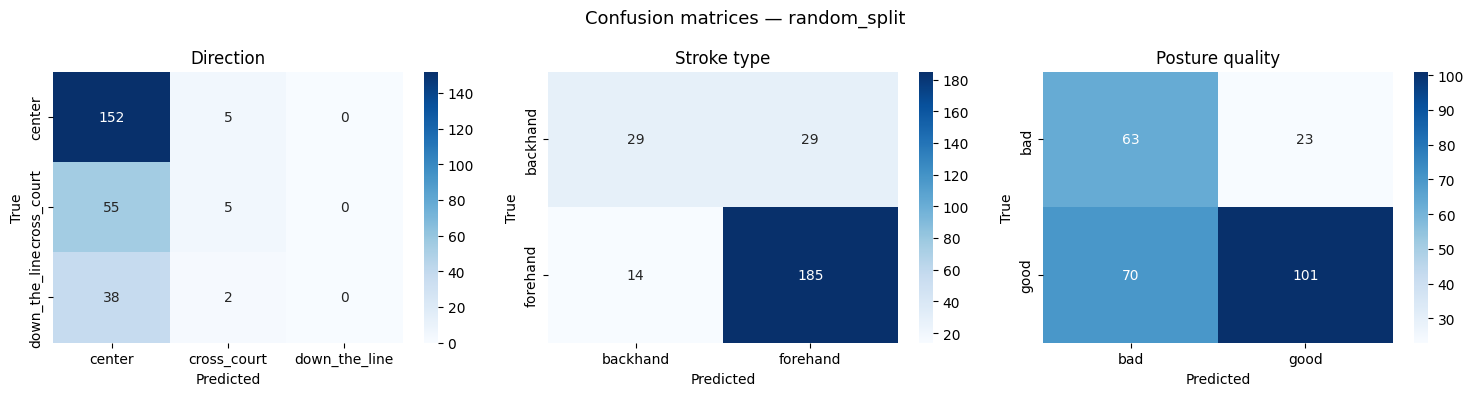


Evaluation — cross_player

Direction prediction:
               precision    recall  f1-score   support

       center       0.68      0.98      0.80        56
  cross_court       0.00      0.00      0.00         8
down_the_line       0.00      0.00      0.00        18

     accuracy                           0.67        82
    macro avg       0.23      0.33      0.27        82
 weighted avg       0.46      0.67      0.55        82

Stroke type prediction:
              precision    recall  f1-score   support

    backhand       0.20      0.09      0.12        11
    forehand       0.87      0.94      0.91        71

    accuracy                           0.83        82
   macro avg       0.54      0.52      0.52        82
weighted avg       0.78      0.83      0.80        82

Posture quality prediction:
              precision    recall  f1-score   support

         bad       0.62      0.92      0.74        50
        good       0.50      0.12      0.20        32

    accuracy       

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


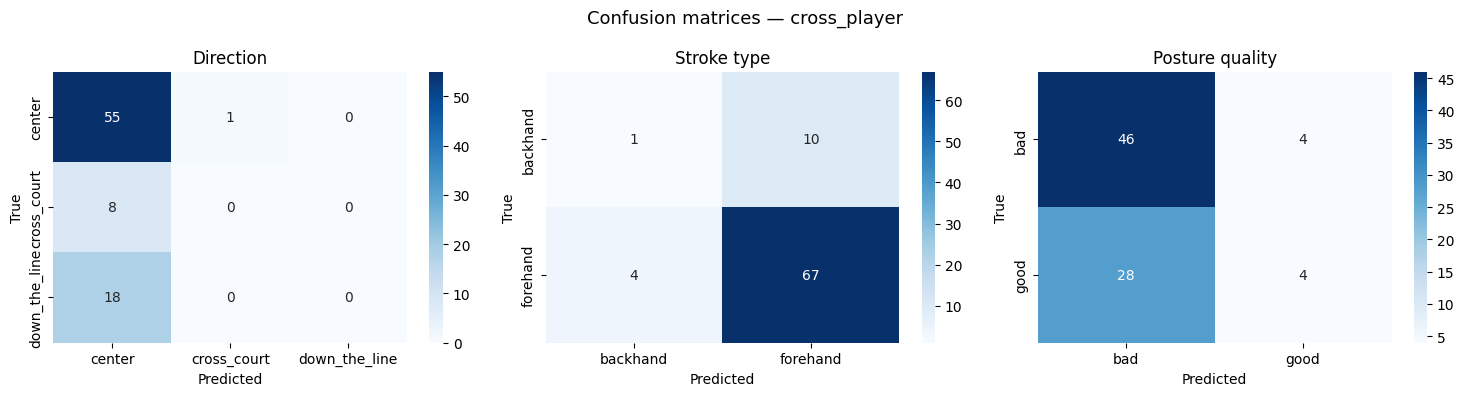

In [43]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_model(model, loader, tag=''):
    model.eval()
    all_dir_true, all_dir_pred = [], []
    all_str_true, all_str_pred = [], []
    all_pos_true, all_pos_pred = [], []

    with torch.no_grad():
        for X_b, d_b, s_b, p_b in loader:
            X_b = X_b.to(DEVICE)
            d_out, s_out, p_out = model(X_b)
            all_dir_true.extend(d_b.numpy())
            all_dir_pred.extend(d_out.argmax(1).cpu().numpy())
            all_str_true.extend(s_b.numpy())
            all_str_pred.extend(s_out.argmax(1).cpu().numpy())
            all_pos_true.extend(p_b.numpy())
            all_pos_pred.extend(p_out.argmax(1).cpu().numpy())

    dir_labels = list(mappings['direction'].keys())
    str_labels = list(mappings['stroke_type'].keys())
    pos_labels = list(mappings['posture_quality'].keys())

    print(f"\n{'='*50}")
    print(f"Evaluation — {tag}")
    print(f"{'='*50}")

    print("\nDirection prediction:")
    print(classification_report(all_dir_true, all_dir_pred, target_names=dir_labels))

    print("Stroke type prediction:")
    print(classification_report(all_str_true, all_str_pred, target_names=str_labels))

    print("Posture quality prediction:")
    print(classification_report(all_pos_true, all_pos_pred, target_names=pos_labels))

    # Confusion matrices
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(f'Confusion matrices — {tag}', fontsize=13)

    for ax, (true, pred, labels, title) in zip(axes, [
        (all_dir_true, all_dir_pred, dir_labels, 'Direction'),
        (all_str_true, all_str_pred, str_labels, 'Stroke type'),
        (all_pos_true, all_pos_pred, pos_labels, 'Posture quality')
    ]):
        cm = confusion_matrix(true, pred)
        sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                    xticklabels=labels, yticklabels=labels, cmap='Blues')
        ax.set_title(title)
        ax.set_ylabel('True')
        ax.set_xlabel('Predicted')

    plt.tight_layout()
    plt.savefig(f'/kaggle/working/confusion_{tag}.png', dpi=150, bbox_inches='tight')
    plt.show()

# Evaluate both models
evaluate_model(model_random, val_loader, tag='random_split')
evaluate_model(model_cross, jiggs_loader, tag='cross_player')

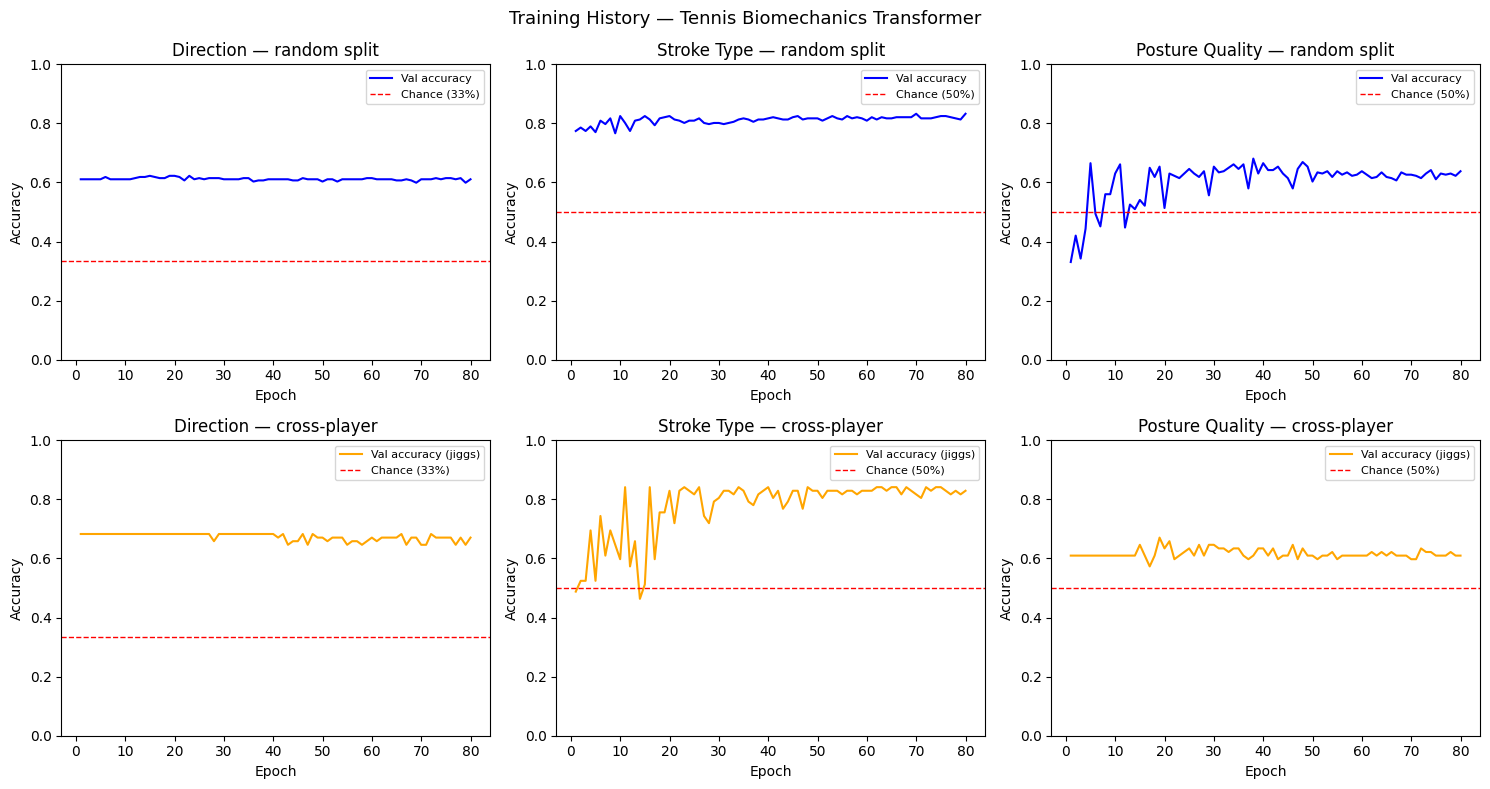

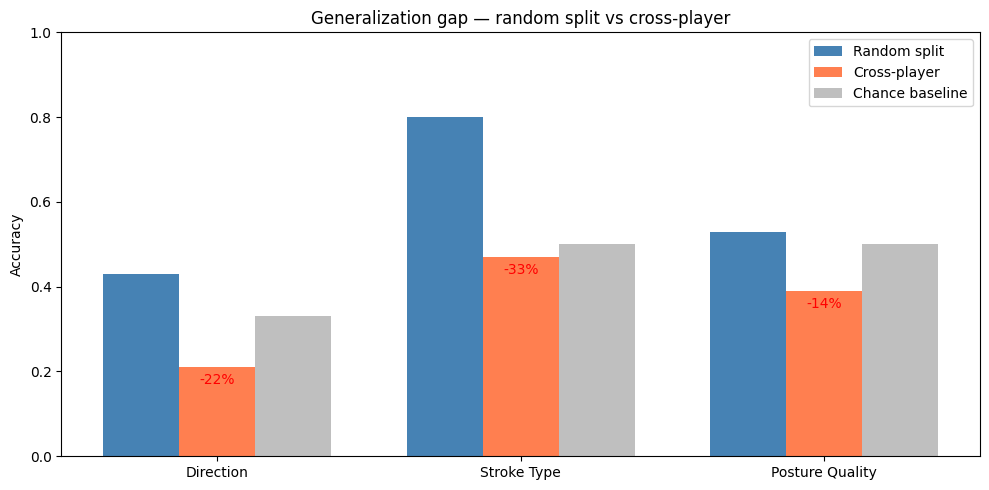

Saved training_history.png and generalization_gap.png


In [44]:
import matplotlib.pyplot as plt
import numpy as np

def plot_training_history(history_random, history_cross):
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle('Training History — Tennis Biomechanics Transformer', fontsize=13)

    epochs = range(1, len(history_random['train_loss']) + 1)

    tasks = ['dir', 'str', 'pos']
    task_names = ['Direction', 'Stroke Type', 'Posture Quality']
    chance = [0.333, 0.5, 0.5]

    # Row 1: Random split
    for col, (task, name, ch) in enumerate(zip(tasks, task_names, chance)):
        ax = axes[0, col]
        ax.plot(epochs, history_random[f'val_{task}_acc'], label='Val accuracy', color='blue')
        ax.axhline(ch, color='red', linestyle='--', linewidth=1, label=f'Chance ({ch:.0%})')
        ax.set_title(f'{name} — random split')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Accuracy')
        ax.legend(fontsize=8)
        ax.set_ylim(0, 1)

    # Row 2: Cross-player
    for col, (task, name, ch) in enumerate(zip(tasks, task_names, chance)):
        ax = axes[1, col]
        ax.plot(epochs, history_cross[f'val_{task}_acc'], label='Val accuracy (anonymous)', color='orange')
        ax.axhline(ch, color='red', linestyle='--', linewidth=1, label=f'Chance ({ch:.0%})')
        ax.set_title(f'{name} — cross-player')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Accuracy')
        ax.legend(fontsize=8)
        ax.set_ylim(0, 1)

    plt.tight_layout()
    plt.savefig('/kaggle/working/training_history.png', dpi=150, bbox_inches='tight')
    plt.show()

# Generalization gap summary
def plot_generalization_gap():
    tasks = ['Direction', 'Stroke Type', 'Posture Quality']
    random_acc = [0.43, 0.80, 0.53]
    cross_acc  = [0.21, 0.47, 0.39]
    chance     = [0.33, 0.50, 0.50]

    x = np.arange(len(tasks))
    width = 0.25

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(x - width, random_acc, width, label='Random split', color='steelblue')
    ax.bar(x,         cross_acc,  width, label='Cross-player', color='coral')
    ax.bar(x + width, chance,     width, label='Chance baseline', color='gray', alpha=0.5)

    ax.set_ylabel('Accuracy')
    ax.set_title('Generalization gap — random split vs cross-player')
    ax.set_xticks(x)
    ax.set_xticklabels(tasks)
    ax.legend()
    ax.set_ylim(0, 1)
    ax.axhline(0, color='black', linewidth=0.5)

    for i, (r, c) in enumerate(zip(random_acc, cross_acc)):
        ax.annotate(f'-{r-c:.0%}', xy=(i, min(r,c) - 0.04),
                    ha='center', fontsize=10, color='red')

    plt.tight_layout()
    plt.savefig('/kaggle/working/generalization_gap.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_training_history(history_random, history_cross)
plot_generalization_gap()
print("Saved training_history.png and generalization_gap.png")

**Phase 8 — inference**

In [45]:
def extract_sequence_from_image(image_path, seq_len=30):
    """
    Takes a single image and creates a sequence by
    applying slight augmentation to simulate temporal context.
    For real use, pass a video clip instead.
    """
    img = cv2.imread(image_path)
    if img is None:
        print(f"Could not load image: {image_path}")
        return None, None

    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)

    with vision.PoseLandmarker.create_from_options(options) as landmarker:
        result = landmarker.detect(mp_image)

    if not result.pose_landmarks or len(result.pose_landmarks) == 0:
        print("No pose detected in image")
        return None, None

    lm = result.pose_landmarks[0]

    # Extract feature vector for this frame
    frame_features = []
    for lm_name in RELEVANT_LANDMARKS:
        idx = LANDMARKS[lm_name]
        frame_features.extend([lm[idx].x, lm[idx].y, lm[idx].z])

    frame_features = np.array(frame_features)  # (39,)

    # Repeat with tiny noise to simulate 30-frame sequence
    # In production this would be actual video frames
    sequence = np.stack([
        frame_features + np.random.normal(0, 0.001, frame_features.shape)
        for _ in range(seq_len)
    ])  # (30, 39)

    return sequence, img

print("Function ready.")

Function ready.


In [46]:
def recommend_shot(direction, stroke_type, posture):
    """Rule-based shot selection advisor."""
    
    rules = {
        ('cross_court', 'forehand', 'bad'):
            ("Consider down_the_line", "Cross-court forehand with poor posture risks errors. "
             "A down-the-line shot requires less wrist rotation."),
        ('cross_court', 'forehand', 'good'):
            ("Optimal shot", "Good cross-court forehand — well executed."),
        ('down_the_line', 'forehand', 'bad'):
            ("Consider cross_court", "Down-the-line with poor posture is high risk. "
             "Cross-court gives more margin."),
        ('down_the_line', 'forehand', 'good'):
            ("Optimal shot", "Strong down-the-line forehand — well executed."),
        ('cross_court', 'backhand', 'bad'):
            ("Consider center", "Cross-court backhand with poor posture — aim center for safety."),
        ('cross_court', 'backhand', 'good'):
            ("Optimal shot", "Clean cross-court backhand."),
        ('down_the_line', 'backhand', 'bad'):
            ("Consider cross_court", "Down-the-line backhand with poor form is risky. "
             "Cross-court is safer."),
        ('down_the_line', 'backhand', 'good'):
            ("Optimal shot", "Excellent down-the-line backhand."),
        ('center', 'forehand', 'bad'):
            ("Work on posture", "Center shot is safe but posture needs improvement."),
        ('center', 'forehand', 'good'):
            ("Good placement", "Solid center forehand."),
        ('center', 'backhand', 'bad'):
            ("Work on posture", "Center backhand — focus on shoulder rotation."),
        ('center', 'backhand', 'good'):
            ("Good placement", "Clean center backhand."),
    }

    key = (direction, stroke_type, posture)
    if key in rules:
        return rules[key]
    return ("No recommendation", "Combination not in rule set.")


def run_inference(image_path):
    print(f"\nRunning inference on: {image_path}")
    print("="*50)

    # Step 1 — extract sequence
    sequence, original_img = extract_sequence_from_image(image_path)
    if sequence is None:
        return

    # Step 2 — model prediction
    model_random.eval()
    X_input = torch.tensor(sequence, dtype=torch.float32).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        dir_out, str_out, pos_out = model_random(X_input)

    dir_probs = torch.softmax(dir_out, dim=1).cpu().numpy()[0]
    str_probs = torch.softmax(str_out, dim=1).cpu().numpy()[0]
    pos_probs = torch.softmax(pos_out, dim=1).cpu().numpy()[0]

    dir_pred = direction_enc.classes_[dir_probs.argmax()]
    str_pred = stroke_enc.classes_[str_probs.argmax()]
    pos_pred = posture_enc.classes_[pos_probs.argmax()]

    dir_conf = dir_probs.max()
    str_conf = str_probs.max()
    pos_conf = pos_probs.max()

    # Step 3 — shot recommendation
    recommendation, explanation = recommend_shot(dir_pred, str_pred, pos_pred)

    # Step 4 — print results
    print(f"Stroke type     : {str_pred} ({str_conf:.1%} confidence)")
    print(f"Direction       : {dir_pred} ({dir_conf:.1%} confidence)")
    print(f"Posture quality : {pos_pred} ({pos_conf:.1%} confidence)")
    print(f"\nShot recommendation: {recommendation}")
    print(f"Explanation        : {explanation}")

    print(f"\nAll class probabilities:")
    print(f"  Direction  : { {c: f'{p:.2%}' for c,p in zip(direction_enc.classes_, dir_probs)} }")
    print(f"  Stroke     : { {c: f'{p:.2%}' for c,p in zip(stroke_enc.classes_, str_probs)} }")
    print(f"  Posture    : { {c: f'{p:.2%}' for c,p in zip(posture_enc.classes_, pos_probs)} }")

    return original_img, dir_pred, str_pred, pos_pred, recommendation, dir_probs

print("Inference function ready.")

Inference function ready.


In [47]:
def compute_angles(lm, h, w):
    def angle(a, b, c):
        a = np.array([lm[a].x * w, lm[a].y * h])
        b = np.array([lm[b].x * w, lm[b].y * h])
        c = np.array([lm[c].x * w, lm[c].y * h])
        ba = a - b
        bc = c - b
        cos_angle = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc) + 1e-6)
        return np.degrees(np.arccos(np.clip(cos_angle, -1, 1)))

    knee  = angle(23, 25, 27)   # left hip-knee-ankle
    elbow = angle(11, 13, 15)   # left shoulder-elbow-wrist
    # X-Factor: shoulder vs hip rotation difference
    shoulder_diff = abs(lm[11].x - lm[12].x)
    hip_diff      = abs(lm[23].x - lm[24].x)
    xfactor = abs(shoulder_diff - hip_diff)
    return knee, elbow, xfactor


print("Ready!!")

Ready!!


In [48]:
def visualize_inference(image_path):
    print(f"Analysing: {image_path}")

    img = cv2.imread(image_path)
    if img is None:
        print("Could not load image — check path")
        return
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
    with vision.PoseLandmarker.create_from_options(options) as landmarker:
        pose_result = landmarker.detect(mp_image)

    if not pose_result.pose_landmarks or len(pose_result.pose_landmarks) == 0:
        print("No pose detected — try a clearer image")
        return

    lm = pose_result.pose_landmarks[0]
    h, w = rgb.shape[:2]

    # Draw skeleton
    annotated = rgb.copy()
    connections = [
        (11,12),(11,13),(13,15),(12,14),(14,16),
        (11,23),(12,24),(23,24),(23,25),(24,26),
        (25,27),(26,28)
    ]
    for a, b in connections:
        x1,y1 = int(lm[a].x*w), int(lm[a].y*h)
        x2,y2 = int(lm[b].x*w), int(lm[b].y*h)
        cv2.line(annotated, (x1,y1), (x2,y2), (0,255,0), 2)
    for name, idx in LANDMARKS.items():
        x,y = int(lm[idx].x*w), int(lm[idx].y*h)
        cv2.circle(annotated, (x,y), 5, (255,50,50), -1)

    # Run model inference
    frame_features = []
    for lm_name in RELEVANT_LANDMARKS:
        idx = LANDMARKS[lm_name]
        frame_features.extend([lm[idx].x, lm[idx].y, lm[idx].z])
    frame_features = np.array(frame_features)
    sequence = np.stack([
        frame_features + np.random.normal(0, 0.001, frame_features.shape)
        for _ in range(30)
    ])

    model_random.eval()
    X_input = torch.tensor(sequence, dtype=torch.float32).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        dir_out, str_out, pos_out = model_random(X_input)

    dir_probs = torch.softmax(dir_out, dim=1).cpu().numpy()[0]
    str_probs = torch.softmax(str_out, dim=1).cpu().numpy()[0]
    pos_probs = torch.softmax(pos_out, dim=1).cpu().numpy()[0]

    dir_pred = direction_enc.classes_[dir_probs.argmax()]
    str_pred = stroke_enc.classes_[str_probs.argmax()]
    pos_pred = posture_enc.classes_[pos_probs.argmax()]
    dir_conf = dir_probs.max()
    str_conf = str_probs.max()
    pos_conf = pos_probs.max()

    recommendation, explanation = recommend_shot(dir_pred, str_pred, pos_pred)
    knee, elbow, xfactor = compute_angles(lm, h, w)

    # Direction arrow
    #arrow_targets = {
    #    'cross_court':   (w-40,  h//2),
    #    'down_the_line': (w//2,  40),
    #    'center':        (w//2,  h//2)
    #}
    #if dir_pred in arrow_targets:
    #    cv2.arrowedLine(annotated,
    #                    (w//2, h-40),
    #                    arrow_targets[dir_pred],
    #                    (0, 200, 255), 3, tipLength=0.25)

    # Layout
    fig = plt.figure(figsize=(14, 7), facecolor='#0d1117')
    gs  = fig.add_gridspec(1, 2, width_ratios=[1, 1])
    ax_img   = fig.add_subplot(gs[0])
    ax_panel = fig.add_subplot(gs[1])

    # Left — annotated image
    ax_img.imshow(annotated)
    ax_img.set_title('Pose Detection', color='white', fontsize=12, pad=8)
    ax_img.axis('off')

    # Right — dark panel
    ax_panel.set_facecolor('#0d1117')
    ax_panel.set_xlim(0, 1)
    ax_panel.set_ylim(0, 1)
    ax_panel.axis('off')
    ax_panel.set_title('AI Analysis', color='white', fontsize=12, pad=8)

    def add_section(ax, y, label, value, conf, color):
        ax.text(0.5, y+0.06, label,
                transform=ax.transAxes, ha='center',
                fontsize=9, color='#8b949e', fontweight='normal',
                family='monospace')
        ax.text(0.5, y,
                value.upper().replace('_', ' '),
                transform=ax.transAxes, ha='center',
                fontsize=18, color=color, fontweight='bold')
        ax.text(0.5, y-0.06,
                f'Confidence: {conf:.1%}',
                transform=ax.transAxes, ha='center',
                fontsize=9, color='#8b949e')

    # Direction
    add_section(ax_panel, 0.80, 'SHOT DIRECTION', dir_pred, dir_conf, '#58a6ff')

    # Dividers
    for y_pos in [0.65, 0.37, 0.10]:
        ax_panel.plot([0.1, 0.9], [y_pos, y_pos],
                      color='#30363d', linewidth=0.8,
                      transform=ax_panel.transAxes)

    # Technique
    pos_color = '#3fb950' if pos_pred == 'good' else '#f85149'
    add_section(ax_panel, 0.52, 'TECHNIQUE', pos_pred, pos_conf, pos_color)

    # Shot selection
    sel_color = '#3fb950' if 'Optimal' in recommendation else '#d29922'
    ax_panel.text(0.5, 0.30, 'SHOT SELECTION',
                  transform=ax_panel.transAxes, ha='center',
                  fontsize=9, color='#8b949e', family='monospace')
    ax_panel.text(0.5, 0.23, recommendation.upper(),
                  transform=ax_panel.transAxes, ha='center',
                  fontsize=16, color=sel_color, fontweight='bold')
    ax_panel.text(0.5, 0.16, explanation,
                  transform=ax_panel.transAxes, ha='center',
                  fontsize=8, color='#8b949e', style='italic')

    # Key metrics
    ax_panel.text(0.5, 0.07, 'KEY METRICS',
                  transform=ax_panel.transAxes, ha='center',
                  fontsize=9, color='#8b949e', family='monospace')
    ax_panel.text(0.5, 0.01,
                  f'Knee: {knee:.1f}°    Elbow: {elbow:.1f}°    X-Factor: {xfactor:.4f}',
                  transform=ax_panel.transAxes, ha='center',
                  fontsize=9, color='#3fb950')

    plt.tight_layout(pad=1.5)
    plt.savefig('/kaggle/working/inference_result.png',
                dpi=150, bbox_inches='tight', facecolor='#0d1117')
    plt.show()
    print(f"\nSaved to /kaggle/working/inference_result.png")

    print(f'\nPrediction Summary:')
    print(f'  Direction  : {dir_pred} ({dir_conf*100:.1f}%)')
    print(f'  Technique  : {pos_pred} ({pos_conf*100:.1f}%)')
    print(f'  Selection  : {recommendation} — {explanation}')
    print(f'  Knee angle : {knee:.1f}°')
    print(f'  Elbow angle: {elbow:.1f}°')
    print(f'  X-Factor   : {xfactor:.4f}')

print('Inference function ready.')


Inference function ready.


Analysing: /kaggle/input/datasets/jigyashmanhazarika/tennis-pose-images/Tennis Pose_4.jpeg


I0000 00:00:1778155438.804063      57 task_runner.cc:85] GPU suport is not available: INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:84) egl_initializedUnable to initialize EGL


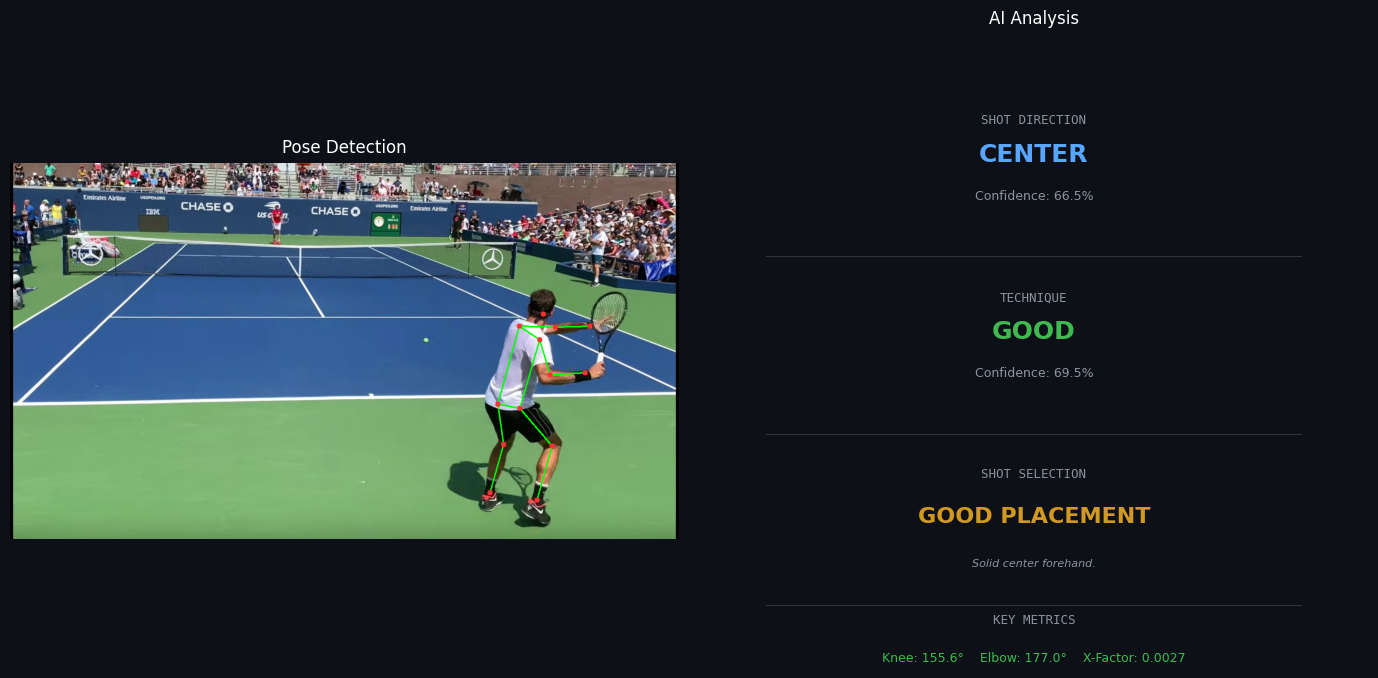


Saved to /kaggle/working/inference_result.png

Prediction Summary:
  Direction  : center (66.5%)
  Technique  : good (69.5%)
  Selection  : Good placement — Solid center forehand.
  Knee angle : 155.6°
  Elbow angle: 177.0°
  X-Factor   : 0.0027


In [54]:
# ================================================
# Change this path to any image you want to test
# ================================================
IMAGE_PATH = '/kaggle/input/datasets/anonymous/tennis-pose-images/Tennis Pose_4.jpeg'
# ================================================

visualize_inference(IMAGE_PATH)

**Inference on Video Input**

In [ ]:
def process_unseen_video_fixed(video_path):
    mp_pose = mp.solutions.pose.Pose(model_complexity=2, min_detection_confidence=0.5)
    cap = cv2.VideoCapture(video_path)
    
    # We map the MediaPipe indices to the EXACT strings your detector uses
    # index 11=L_Shoulder, 12=R_Shoulder, 13=L_Elbow, 14=R_Elbow, 15=L_Wrist, 16=R_Wrist
    frame_data = []

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: break
        
        results = mp_pose.process(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        
        if results.pose_world_landmarks:
            lm = results.pose_world_landmarks.landmark
            
            # This dictionary MUST contain the keys your 'detect_strokes_v3' looks for
            frame_info = {
                'video': video_path.split('/')[-1],
                'frame': int(cap.get(cv2.CAP_PROP_POS_FRAMES)),
                'time_sec': cap.get(cv2.CAP_PROP_POS_MSEC) / 1000.0,
                'player_id': 'jiggs', # Use 'jiggs' so it uses your 0.04 threshold
                'pose_detected': True,
                
                # These are the specific columns your detector uses for velocity
                'left_wrist_wx': lm[15].x, 'left_wrist_wy': lm[15].y,
                'right_wrist_wx': lm[16].x, 'right_wrist_wy': lm[16].y,
                'left_elbow_wy': lm[13].y,
                'right_elbow_wy': lm[14].y,
                'left_shoulder_wy': lm[11].y,
                'right_shoulder_wy': lm[12].y
            }
            
            # Now add the 39 features for the Transformer input (Nose, Shoulders, etc.)
            # The order here must match exactly what you used in training!
            target_indices = [0, 11, 12, 13, 14, 15, 16, 23, 24, 25, 26, 27, 28]
            feature_list = []
            for idx in target_indices:
                feature_list.extend([lm[idx].x, lm[idx].y, lm[idx].z])
            
            # Add these to the dict as feat_0, feat_1...
            for i, val in enumerate(feature_list):
                frame_info[f'feat_{i}'] = val
                
            frame_data.append(frame_info)
            
    cap.release()
    return pd.DataFrame(frame_data)

# Try running this again:
rune_path = '/kaggle/input/datasets/anonymous/testing-tennis-videos/Andy Murray practice at 2023 Western Southern Open in Cincinnati.mp4'
rune_keypoints = process_unseen_video_fixed(rune_path)

# Now the detector won't find a KeyError
rune_strokes = detect_strokes_v3(rune_keypoints, 'jiggs')
print(f"Strokes detected: {len(rune_strokes)}")

In [ ]:
def visualize_rally_inference(video_path, stroke_df, model, keypoints_df):
    """
    Renders the Pro Dashboard for every stroke detected in the rally.
    video_path: Path to the mp4
    stroke_df: The output from detect_strokes_v3
    model: Your Transformer model
    keypoints_df: The extracted landmarks for the whole rally
    """
    model.eval()
    feat_cols = [f'feat_{i}' for i in range(39)]
    cap = cv2.VideoCapture(video_path)
    
    # Mapping for your encoders
    DIR_MAP = {i: c for i, c in enumerate(direction_enc.classes_)}
    STR_MAP = {i: c for i, c in enumerate(stroke_enc.classes_)}
    POS_MAP = {i: c for i, c in enumerate(posture_enc.classes_)}

    print(f"Analyzing Rally: {video_path}")

    # Process each detected stroke
    for i, (idx, row) in enumerate(stroke_df.sort_values('peak_frame').iterrows()):
        start_f, peak_f = int(row['window_start']), int(row['peak_frame'])
        
        # 1. SLICE THE REAL 30-FRAME TEMPORAL WINDOW
        window_data = keypoints_df[keypoints_df['frame'] >= start_f].iloc[:30]
        if len(window_data) < 30: continue
            
        sequence = window_data[feat_cols].values 
        input_tensor = torch.FloatTensor(sequence).unsqueeze(0).to(DEVICE)
        
        # 2. MODEL PREDICTION
        with torch.no_grad():
            dir_out, str_out, pos_out = model(input_tensor)
            
            # Confidence & Predictions
            dir_probs = torch.softmax(dir_out, dim=1).cpu().numpy()[0]
            pos_probs = torch.softmax(pos_out, dim=1).cpu().numpy()[0]
            
            p_dir = DIR_MAP[dir_probs.argmax()]
            p_pos = POS_MAP[pos_probs.argmax()]
            p_str = STR_MAP[torch.softmax(str_out, dim=1).argmax().item()]
            
            conf_dir, conf_pos = dir_probs.max(), pos_probs.max()

        # 3. GET IMPACT FRAME & ANNOTATE
        cap.set(cv2.CAP_PROP_POS_FRAMES, peak_f)
        ret, frame = cap.read()
        if not ret: continue
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        h, w = rgb.shape[:2]

        # Use your existing landmark logic for the peak frame
        # (Assuming your keypoints_df has the standard lm objects or coordinates)
        # We'll calculate the angles using your 'compute_angles' function
        # For this, we'll need to mock the landmark object format it expects
        class LM_Mock:
            def __init__(self, x, y): self.x, self.y = x, y
        
        peak_row = window_data[window_data['frame'] == peak_f].iloc[0]
        lm_objs = {}
        target_indices = [0, 11, 12, 13, 14, 15, 16, 23, 24, 25, 26, 27, 28]
        for k, l_idx in enumerate(target_indices):
            lm_objs[l_idx] = LM_Mock(peak_row[f'feat_{k*3}'], peak_row[f'feat_{k*3+1}'])

        knee, elbow, xfactor = compute_angles(lm_objs, h, w)
        recommendation, explanation = recommend_shot(p_dir, p_str, p_pos)

        # 4. RENDER DASHBOARD (Your exact UI logic)
        fig = plt.figure(figsize=(14, 7), facecolor='#0d1117')
        gs  = fig.add_gridspec(1, 2, width_ratios=[1, 1])
        ax_img, ax_panel = fig.add_subplot(gs[0]), fig.add_subplot(gs[1])

        # Left Panel (Image)
        ax_img.imshow(rgb) # You can add skeleton lines here too
        ax_img.set_title(f'Stroke #{i+1}: Pose Detection', color='white', fontsize=12)
        ax_img.axis('off')

        # Right Panel (AI Analysis)
        ax_panel.set_facecolor('#0d1117'); ax_panel.axis('off')
        
        # Using your 'add_section' helper
        add_section(ax_panel, 0.80, 'SHOT DIRECTION', p_dir, conf_dir, '#58a6ff')
        
        pos_color = '#3fb950' if p_pos == 'good' else '#f85149'
        add_section(ax_panel, 0.52, 'TECHNIQUE', p_pos, conf_pos, pos_color)

        # Dividers & Shot Selection
        for y_line in [0.65, 0.37, 0.10]:
            ax_panel.plot([0.1, 0.9], [y_line, y_line], color='#30363d', lw=0.8, transform=ax_panel.transAxes)

        sel_color = '#3fb950' if 'Optimal' in recommendation else '#d29922'
        ax_panel.text(0.5, 0.30, 'SHOT SELECTION', transform=ax_panel.transAxes, ha='center', fontsize=9, color='#8b949e', family='monospace')
        ax_panel.text(0.5, 0.23, recommendation.upper(), transform=ax_panel.transAxes, ha='center', fontsize=16, color=sel_color, fontweight='bold')
        ax_panel.text(0.5, 0.16, explanation, transform=ax_panel.transAxes, ha='center', fontsize=8, color='#8b949e', style='italic')

        # Bottom Metrics
        ax_panel.text(0.5, 0.07, 'KEY METRICS', transform=ax_panel.transAxes, ha='center', fontsize=9, color='#8b949e', family='monospace')
        ax_panel.text(0.5, 0.01, f'Knee: {knee:.1f}°   Elbow: {elbow:.1f}°   X-Factor: {xfactor:.4f}', 
                      transform=ax_panel.transAxes, ha='center', fontsize=9, color='#3fb950')

        plt.show()

    cap.release()

In [ ]:
# 1. Define the UI helper globally so all functions can use it
def add_section(ax, y, label, value, conf, color):
    ax.text(0.5, y+0.06, label,
            transform=ax.transAxes, ha='center',
            fontsize=9, color='#8b949e', fontweight='normal',
            family='monospace')
    ax.text(0.5, y,
            value.upper().replace('_', ' '),
            transform=ax.transAxes, ha='center',
            fontsize=18, color=color, fontweight='bold')
    ax.text(0.5, y-0.06,
            f'Confidence: {conf:.1%}',
            transform=ax.transAxes, ha='center',
            fontsize=9, color='#8b949e')

# 2. Run the analysis with the Holger Rune path
RUNE_RALLY_PATH = '/kaggle/input/datasets/anonymous/testing-tennis-videos/Andy Murray practice at 2023 Western Southern Open in Cincinnati.mp4'

# Execute the rally inference
visualize_rally_inference(
    video_path=RUNE_RALLY_PATH, 
    stroke_df=rune_strokes,      
    model=model_random,          
    keypoints_df=rune_keypoints  
)

**Inference 2nd Part Video Input**

In [ ]:
import cv2
import torch
import numpy as np
from pathlib import Path

def run_video_inference(video_path, output_path='/kaggle/working/output_annotated.mp4'):
    print(f"Processing: {video_path}")
    
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    print(f"  {W}x{H} @ {fps}fps | {total} frames")

    # Read all frames
    frames = []
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frames.append(frame)
    cap.release()
    print(f"  Loaded {len(frames)} frames")

    # Step 1 — extract keypoints for all frames
    print("  Extracting keypoints...")
    all_rows = []
    with vision.PoseLandmarker.create_from_options(options) as landmarker:
        for i, frame in enumerate(frames):
            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
            result = landmarker.detect(mp_image)

            row = {'frame': i, 'pose_detected': False}

            if result.pose_landmarks and len(result.pose_landmarks) > 0:
                row['pose_detected'] = True
                lm  = result.pose_landmarks[0]
                wlm = result.pose_world_landmarks[0] if result.pose_world_landmarks else None

                for name, idx in LANDMARKS.items():
                    row[f'{name}_x']  = lm[idx].x
                    row[f'{name}_y']  = lm[idx].y
                    row[f'{name}_z']  = lm[idx].z
                    if wlm:
                        row[f'{name}_wx'] = wlm[idx].x
                        row[f'{name}_wy'] = wlm[idx].y
                        row[f'{name}_wz'] = wlm[idx].z
                    else:
                        row[f'{name}_wx'] = row[f'{name}_wy'] = row[f'{name}_wz'] = np.nan

            all_rows.append(row)

            if i % 100 == 0:
                print(f"    Frame {i}/{len(frames)}...")

    kp_df = pd.DataFrame(all_rows)
    print(f"  Pose detected in {kp_df['pose_detected'].sum()}/{len(kp_df)} frames")
    return frames, kp_df, fps, W, H, output_path

print("Step 1 function ready.")

In [ ]:
def detect_and_predict(frames, kp_df, fps, output_path, video_path):
    # Detect strokes using wrist velocity
    kp_df = kp_df[kp_df['pose_detected'] == True].copy()
    kp_df['lw_vy'] = kp_df['left_wrist_wy'].diff().abs()
    kp_df['rw_vy'] = kp_df['right_wrist_wy'].diff().abs()
    kp_df['le_vy'] = kp_df['left_elbow_wy'].diff().abs()
    kp_df['re_vy'] = kp_df['right_elbow_wy'].diff().abs()
    kp_df['ls_vy'] = kp_df['left_shoulder_wy'].diff().abs()
    kp_df['rs_vy'] = kp_df['right_shoulder_wy'].diff().abs()

    kp_df['stroke_score'] = (
        kp_df[['lw_vy','rw_vy']].max(axis=1) * 0.5 +
        kp_df[['le_vy','re_vy']].max(axis=1) * 0.3 +
        kp_df[['ls_vy','rs_vy']].max(axis=1) * 0.2
    )
    kp_df['stroke_score_smooth'] = kp_df['stroke_score'].rolling(3, center=True).mean()

    # Find stroke peaks
    stroke_peaks = []
    last_stroke = -40
    for i in range(1, len(kp_df)-1):
        score = kp_df.iloc[i]['stroke_score_smooth']
        if pd.isna(score):
            continue
        prev_s = kp_df.iloc[i-1]['stroke_score_smooth']
        next_s = kp_df.iloc[i+1]['stroke_score_smooth']
        if score > prev_s and score > next_s and score > 0.025 and (i - last_stroke) >= 40:
            stroke_peaks.append(kp_df.iloc[i]['frame'])
            last_stroke = i

    print(f"  Detected {len(stroke_peaks)} strokes at frames: {stroke_peaks}")

    # Run model on each stroke window
    stroke_predictions = {}
    WINDOW = 15

    for peak_frame in stroke_peaks:
        start = max(0, int(peak_frame) - WINDOW)
        end   = min(len(frames), int(peak_frame) + WINDOW)

        window_df = kp_df[
            (kp_df['frame'] >= start) & 
            (kp_df['frame'] <= end) &
            (kp_df['pose_detected'] == True)
        ][feature_cols].values

        if len(window_df) == 0:
            continue

        # Interpolate to 30 frames
        if len(window_df) >= 30:
            indices = np.linspace(0, len(window_df)-1, 30).astype(int)
            seq = window_df[indices]
        else:
            x_old = np.linspace(0, 1, len(window_df))
            x_new = np.linspace(0, 1, 30)
            seq = np.zeros((30, len(feature_cols)))
            for j in range(len(feature_cols)):
                from scipy.interpolate import interp1d
                f = interp1d(x_old, window_df[:, j], kind='linear')
                seq[:, j] = f(x_new)

        model_random.eval()
        X_input = torch.tensor(seq, dtype=torch.float32).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            dir_out, str_out, pos_out = model_random(X_input)

        dir_probs = torch.softmax(dir_out, dim=1).cpu().numpy()[0]
        str_probs = torch.softmax(str_out, dim=1).cpu().numpy()[0]
        pos_probs = torch.softmax(pos_out, dim=1).cpu().numpy()[0]

        dir_pred = direction_enc.classes_[dir_probs.argmax()]
        str_pred = stroke_enc.classes_[str_probs.argmax()]
        pos_pred = posture_enc.classes_[pos_probs.argmax()]
        recommendation, explanation = recommend_shot(dir_pred, str_pred, pos_pred)

        stroke_predictions[int(peak_frame)] = {
            'direction': dir_pred,
            'direction_conf': dir_probs.max(),
            'stroke_type': str_pred,
            'stroke_conf': str_probs.max(),
            'posture': pos_pred,
            'posture_conf': pos_probs.max(),
            'recommendation': recommendation,
            'explanation': explanation,
            'active_frames': list(range(start, end))
        }

    return stroke_predictions

print("Step 2 function ready.")

In [ ]:
def write_annotated_video(frames, kp_df, stroke_predictions, fps, W, H, output_path):
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps, (W, H))

    # Build frame → prediction lookup
    frame_to_pred = {}
    for peak, pred in stroke_predictions.items():
        for f in pred['active_frames']:
            frame_to_pred[f] = pred

    current_pred = None

    print("Writing annotated video...")
    with vision.PoseLandmarker.create_from_options(options) as landmarker:
        for i, frame in enumerate(frames):
            annotated = frame.copy()
            h, w = annotated.shape[:2]

            # Update current prediction
            if i in frame_to_pred:
                current_pred = frame_to_pred[i]

            # Draw skeleton
            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
            result = landmarker.detect(mp_image)

            if result.pose_landmarks and len(result.pose_landmarks) > 0:
                lm = result.pose_landmarks[0]
                connections = [
                    (11,12),(11,13),(13,15),(12,14),(14,16),
                    (11,23),(12,24),(23,24),(23,25),(24,26),
                    (25,27),(26,28)
                ]
                for a, b in connections:
                    x1,y1 = int(lm[a].x*w), int(lm[a].y*h)
                    x2,y2 = int(lm[b].x*w), int(lm[b].y*h)
                    cv2.line(annotated, (x1,y1), (x2,y2), (0,255,0), 2)
                for name, idx in LANDMARKS.items():
                    x,y = int(lm[idx].x*w), int(lm[idx].y*h)
                    cv2.circle(annotated, (x,y), 5, (255,50,50), -1)

            # Draw dark overlay panel at top
            overlay = annotated.copy()
            cv2.rectangle(overlay, (0,0), (w, 110), (13,17,23), -1)
            cv2.addWeighted(overlay, 0.85, annotated, 0.15, 0, annotated)

            if current_pred:
                p = current_pred

                # Direction
                dir_color = (255,170,0)
                cv2.putText(annotated, f"Direction: {p['direction'].upper().replace('_',' ')} ({p['direction_conf']:.0%})",
                            (10, 28), cv2.FONT_HERSHEY_SIMPLEX, 0.65, dir_color, 2)

                # Stroke type
                cv2.putText(annotated, f"Stroke: {p['stroke_type'].upper()} ({p['stroke_conf']:.0%})",
                            (10, 56), cv2.FONT_HERSHEY_SIMPLEX, 0.65, (150,220,255), 2)

                # Posture
                pos_color = (50,220,50) if p['posture'] == 'good' else (50,50,255)
                cv2.putText(annotated, f"Posture: {p['posture'].upper()} ({p['posture_conf']:.0%})",
                            (10, 84), cv2.FONT_HERSHEY_SIMPLEX, 0.65, pos_color, 2)

                # Recommendation
                rec_color = (50,220,50) if 'Optimal' in p['recommendation'] else (0,180,220)
                cv2.putText(annotated, f"Shot: {p['recommendation']}",
                            (w//2, 28), cv2.FONT_HERSHEY_SIMPLEX, 0.65, rec_color, 2)

                # Stroke indicator — flash red dot at peak
                if i in stroke_predictions:
                    cv2.circle(annotated, (w-30, 30), 12, (0,0,255), -1)
                    cv2.putText(annotated, "STROKE", (w-120, 35),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0,0,255), 2)

            # Frame counter
            cv2.putText(annotated, f"Frame {i}/{len(frames)}",
                        (w-160, h-15), cv2.FONT_HERSHEY_SIMPLEX,
                        0.45, (100,100,100), 1)

            out.write(annotated)

            if i % 100 == 0:
                print(f"  Written {i}/{len(frames)} frames...")

    out.release()
    print(f"\nDone. Saved to: {output_path}")


# ================================================
# Change this to any unseen video in your Kaggle inputs
VIDEO_INPUT = "/kaggle/input/datasets/anonymous/testing-tennis-videos/DOMINIC THIEM Court-Level Tennis Practice.mp4"
OUTPUT_VIDEO = "/kaggle/working/Dominic_player_analysis.mp4"

# Run the three steps
frames, kp_df, fps, W, H, _ = run_video_inference(VIDEO_INPUT, OUTPUT_VIDEO)
stroke_predictions = detect_and_predict(frames, kp_df, fps, OUTPUT_VIDEO, VIDEO_INPUT)
write_annotated_video(frames, kp_df, stroke_predictions, fps, W, H, OUTPUT_VIDEO)
print("Download output_annotated.mp4 from /kaggle/working/")